In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [4]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [13]:
dbd_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_end", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
dbd_norm_activities

,ADseq,AD_end,AD_BC,RPTR_BC,time,rep,shifted_activity
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,0,2,-0.150595
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,0,2,-0.329160
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,AATCGTACCGA,TTTGATATCCAAAC,0,2,-0.396107
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTGCATAGCTG,TATTGTTCTCTGCT,0,2,-0.748290
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTTATAATACC,CATCGAACCTGAAC,0,2,-0.073888
...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,CCAAACTTGGA,CAATTGACACTACG,60,4,-0.375924
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,CCCACTCTCAG,CGCACGAATACCCG,60,4,-0.207950
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GGGTCGTAAAT,CAACAGCCCTTACG,60,4,0.320323
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,60,4,0.324968


# Propagating bio and tech error

In [15]:
bio_tech_rep_err = tech_rep_err.groupby(["ADseq", "AD_end", "time"]).agg(
    grand_mean=("mean", "mean"),        # Step 2: grand mean
    s_bio=("mean", "std"),              # Step 3: SD across bio rep means
    n_bio=("mean", "count"),            # number of biological replicates
    SE_tech_sq_mean=("SE_tech_sq", "mean")  # Step 4: mean squared technical SE
).reset_index()
bio_tech_rep_err

,ADseq,AD_end,time,grand_mean,s_bio,n_bio,SE_tech_sq_mean
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,15,1.460117,NaN,1,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,30,0.755067,NaN,1,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,0.186882,0.080018,3,0.000694
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,0.340462,0.047206,3,0.069249
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,0.467590,0.333105,3,0.007825
...,...,...,...,...,...,...,...
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,0.307908,0.710601,2,0.011365
164686,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,30,0.251165,0.866234,2,0.000589
164687,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,40,-0.270341,NaN,1,0.003938
164688,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,50,-0.226925,NaN,1,0.014377


In [16]:
# Step 3 — combine
bio_tech_rep_err["SE_final"] = np.sqrt(
    (bio_tech_rep_err["s_bio"]**2 + bio_tech_rep_err["SE_tech_sq_mean"])
    / bio_tech_rep_err["n_bio"]
)
bio_tech_rep_err

,ADseq,AD_end,time,grand_mean,s_bio,n_bio,SE_tech_sq_mean,SE_final
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,15,1.460117,NaN,1,NaN,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,30,0.755067,NaN,1,NaN,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,0.186882,0.080018,3,0.000694,0.048638
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,0.340462,0.047206,3,0.069249,0.154356
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,0.467590,0.333105,3,0.007825,0.198984
...,...,...,...,...,...,...,...,...
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,0.307908,0.710601,2,0.011365,0.508094
164686,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,30,0.251165,0.866234,2,0.000589,0.612760
164687,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,40,-0.270341,NaN,1,0.003938,NaN
164688,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,50,-0.226925,NaN,1,0.014377,NaN


In [18]:
bio_tech_rep_err_mult_meas = bio_tech_rep_err.dropna()
bio_tech_rep_err_mult_meas

,ADseq,AD_end,time,grand_mean,s_bio,n_bio,SE_tech_sq_mean,SE_final
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,0.186882,0.080018,3,0.000694,0.048638
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,0.340462,0.047206,3,0.069249,0.154356
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,0.467590,0.333105,3,0.007825,0.198984
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,10,0.239009,0.212394,3,0.024297,0.152106
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,15,0.190206,0.112335,3,0.027642,0.115846
...,...,...,...,...,...,...,...,...
164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,TGTTTGGAATGTTGCTAAATTGCCAAATATCTTGGATCAT,60,0.736019,0.274903,4,0.006839,0.143536
164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,5,-0.084863,0.715209,2,0.029830,0.520266
164683,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,10,-0.011900,0.293554,2,0.011692,0.221209
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,0.307908,0.710601,2,0.011365,0.508094


# Linear model

In [22]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm import tqdm


warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

groups = [(adseq, ad_end, time, grp)
          for (adseq, ad_end, time), grp
          in dbd_norm_activities.groupby(["ADseq", "AD_end", "time"])]

print(f"Fitting {len(groups)} groups...")

results = []

for adseq, ad_end, time, grp in tqdm(groups, desc="Fitting models"):
    grp = grp.copy()
    n_bio = grp['bio_rep'].nunique()
    n_tech_mean = grp.groupby('bio_rep').size().mean()
    base = {"ADseq": adseq, "AD_end": ad_end, "time": time,
            "n_bio": n_bio, "n_tech": n_tech_mean}

    if n_bio < 2:
        tech_se = grp.groupby('bio_rep')['shifted_activity'].mean().sem()
        results.append({**base,
                "grand_mean": grp['shifted_activity'].mean(),
                "SE_final": tech_se,ca
                "sigma2_bio": np.nan,
                "sigma2_tech": grp['shifted_activity'].var(),
                "flag": "single_bio_rep"})
        continue

    try:
        model = MixedLM(
            endog=grp['shifted_activity'],
            exog=np.ones(len(grp)),
            groups=grp['bio_rep'],
        )
        try:
            fit = model.fit(reml=True, method='lbfgs')
        except Exception:
            fit = model.fit(reml=True, method='nm', maxiter=1000)

        results.append({**base,
                "grand_mean": fit.fe_params.iloc[0],
                "SE_final": fit.bse_fe.iloc[0],
                "sigma2_bio": float(fit.cov_re.iloc[0, 0]),
                "sigma2_tech": fit.scale,
                "flag": "ok"})

    except Exception as e:
        results.append({**base,
                "grand_mean": grp['shifted_activity'].mean(),
                "SE_final": np.nan,
                "sigma2_bio": np.nan,
                "sigma2_tech": np.nan,
                "flag": f"model_error: {e}"})

final_results = pd.DataFrame(results)

print("\n--- Flag summary ---")
print(final_results['flag'].value_counts())
print("\n--- Variance components ---")
print(final_results[['sigma2_bio', 'sigma2_tech']].describe())
print("\n--- n_bio distribution ---")
print(final_results['n_bio'].value_counts().sort_index())

final_results

Fitting 164690 groups...


Fitting models: 100%|██████████| 164690/164690 [31:32<00:00, 87.04it/s] 



--- Flag summary ---
flag
ok                              131434
single_bio_rep                   33111
model_error: Singular matrix       145
Name: count, dtype: int64

--- Variance components ---
         sigma2_bio    sigma2_tech
count  1.314340e+05  159371.000000
mean   6.092400e-02       0.064442
std    1.206860e-01       0.063500
min    0.000000e+00       0.000000
25%    4.435774e-09       0.024588
50%    1.889339e-02       0.049162
75%    7.070752e-02       0.084470
max    4.927861e+00       2.238957

--- n_bio distribution ---
n_bio
1     33111
2     37586
3     33590
4     24166
5     15834
6      9409
7      4901
8      2614
9      1450
10      640
11      409
12      226
13      125
14       85
15       73
16       48
17       51
18       42
19       25
20       21
21       43
22       15
23       16
24       20
25       14
26       19
27       17
28       12
29        8
31       10
32       21
33       23
34       21
35        6
36        5
37        2
38        3
40      

,ADseq,AD_end,time,n_bio,n_tech,grand_mean,SE_final,sigma2_bio,sigma2_tech,flag
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,15,1,1.000000,1.460117,NaN,NaN,NaN,single_bio_rep
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,30,1,1.000000,0.755067,NaN,NaN,NaN,single_bio_rep
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,3,1.666667,0.191781,0.046523,4.781609e-03,0.002082,ok
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,3,2.000000,0.356032,0.102500,2.445629e-09,0.064111,ok
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,3,2.666667,0.469725,0.193822,1.026701e-01,0.025839,ok
...,...,...,...,...,...,...,...,...,...,...
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,2,2.000000,0.296599,0.502719,4.822094e-01,0.034097,ok
164686,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,30,2,2.000000,0.250684,0.612515,7.491697e-01,0.001767,ok
164687,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,40,1,3.000000,-0.270341,NaN,NaN,0.011814,single_bio_rep
164688,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,50,1,3.000000,-0.226925,NaN,NaN,0.043131,single_bio_rep


In [23]:
final_results.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_error_propagated.csv")

In [21]:
final_results = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_error_propagated.csv")
final_results

,Unnamed: 0,ADseq,AD_end,time,n_bio,n_tech,grand_mean,SE_final,sigma2_bio,sigma2_tech,flag
0,0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,15,1,1.000000,1.460117,NaN,NaN,NaN,single_bio_rep
1,1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,TTCTTCTTTGAAGAATGATTTGTCTAATATTTCTAATTCT,30,1,1.000000,0.755067,NaN,NaN,NaN,single_bio_rep
2,2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,3,1.666667,0.191781,0.046523,4.781609e-03,0.002082,ok
3,3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,3,2.000000,0.356032,0.102500,2.445629e-09,0.064111,ok
4,4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,3,2.666667,0.469725,0.193822,1.026701e-01,0.025839,ok
...,...,...,...,...,...,...,...,...,...,...,...
164685,164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,2,2.000000,0.296599,0.502719,4.822094e-01,0.034097,ok
164686,164686,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,30,2,2.000000,0.250684,0.612515,7.491697e-01,0.001767,ok
164687,164687,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,40,1,3.000000,-0.270341,NaN,NaN,0.011814,single_bio_rep
164688,164688,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,50,1,3.000000,-0.226925,NaN,NaN,0.043131,single_bio_rep


<Axes: xlabel='time', ylabel='sigma2_tech'>

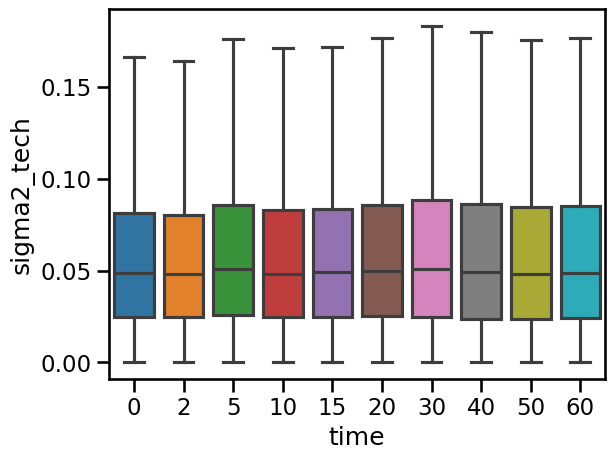

In [25]:
sns.boxplot(data = final_results, x = "time", y = "sigma2_tech", showfliers = False)

<Axes: xlabel='time', ylabel='sigma2_bio'>

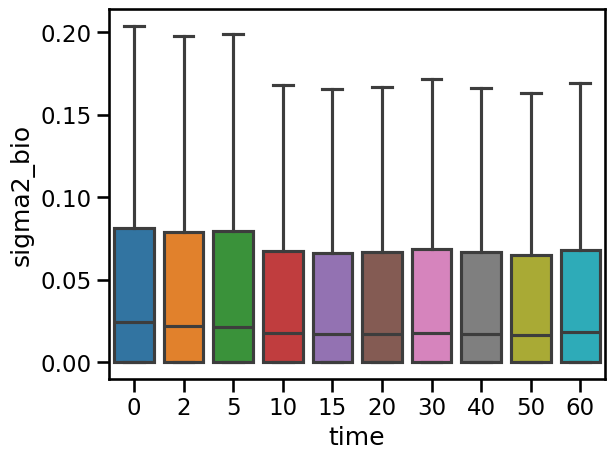

In [26]:
sns.boxplot(data = final_results, x = "time", y = "sigma2_bio", showfliers = False)

# Activity vs propogated error plotted

In [38]:
final_results = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_error_propagated.csv")
final_results = final_results.dropna()
final_results

,Unnamed: 0,ADseq,AD_end,time,n_bio,n_tech,grand_mean,SE_final,sigma2_bio,sigma2_tech,flag
2,2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,0,3,1.666667,0.191781,0.046523,4.781609e-03,0.002082,ok
3,3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,2,3,2.000000,0.356032,0.102500,2.445629e-09,0.064111,ok
4,4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,5,3,2.666667,0.469725,0.193822,1.026701e-01,0.025839,ok
5,5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,10,3,2.000000,0.194010,0.153025,1.750592e-09,0.045891,ok
6,6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,GGATGATAATTCTCAAAATTCTATGGTTCCAGCTCCATCT,15,3,2.000000,0.173738,0.118937,2.670098e-09,0.069995,ok
...,...,...,...,...,...,...,...,...,...,...,...
164679,164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,TGTTTGGAATGTTGCTAAATTGCCAAATATCTTGGATCAT,60,4,3.000000,0.736019,0.137452,6.873344e-02,0.020517,ok
164682,164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,5,2,2.000000,-0.114355,0.507444,4.518604e-01,0.089489,ok
164683,164683,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,10,2,2.000000,-0.040065,0.211361,6.278882e-02,0.035077,ok
164685,164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,TTTGGATAAAAATTCTGAACCAAATGGTTATATGTGTCCA,20,2,2.000000,0.296599,0.502719,4.822094e-01,0.034097,ok


In [39]:
final_results["flag"].value_counts()

flag
ok    128973
Name: count, dtype: int64

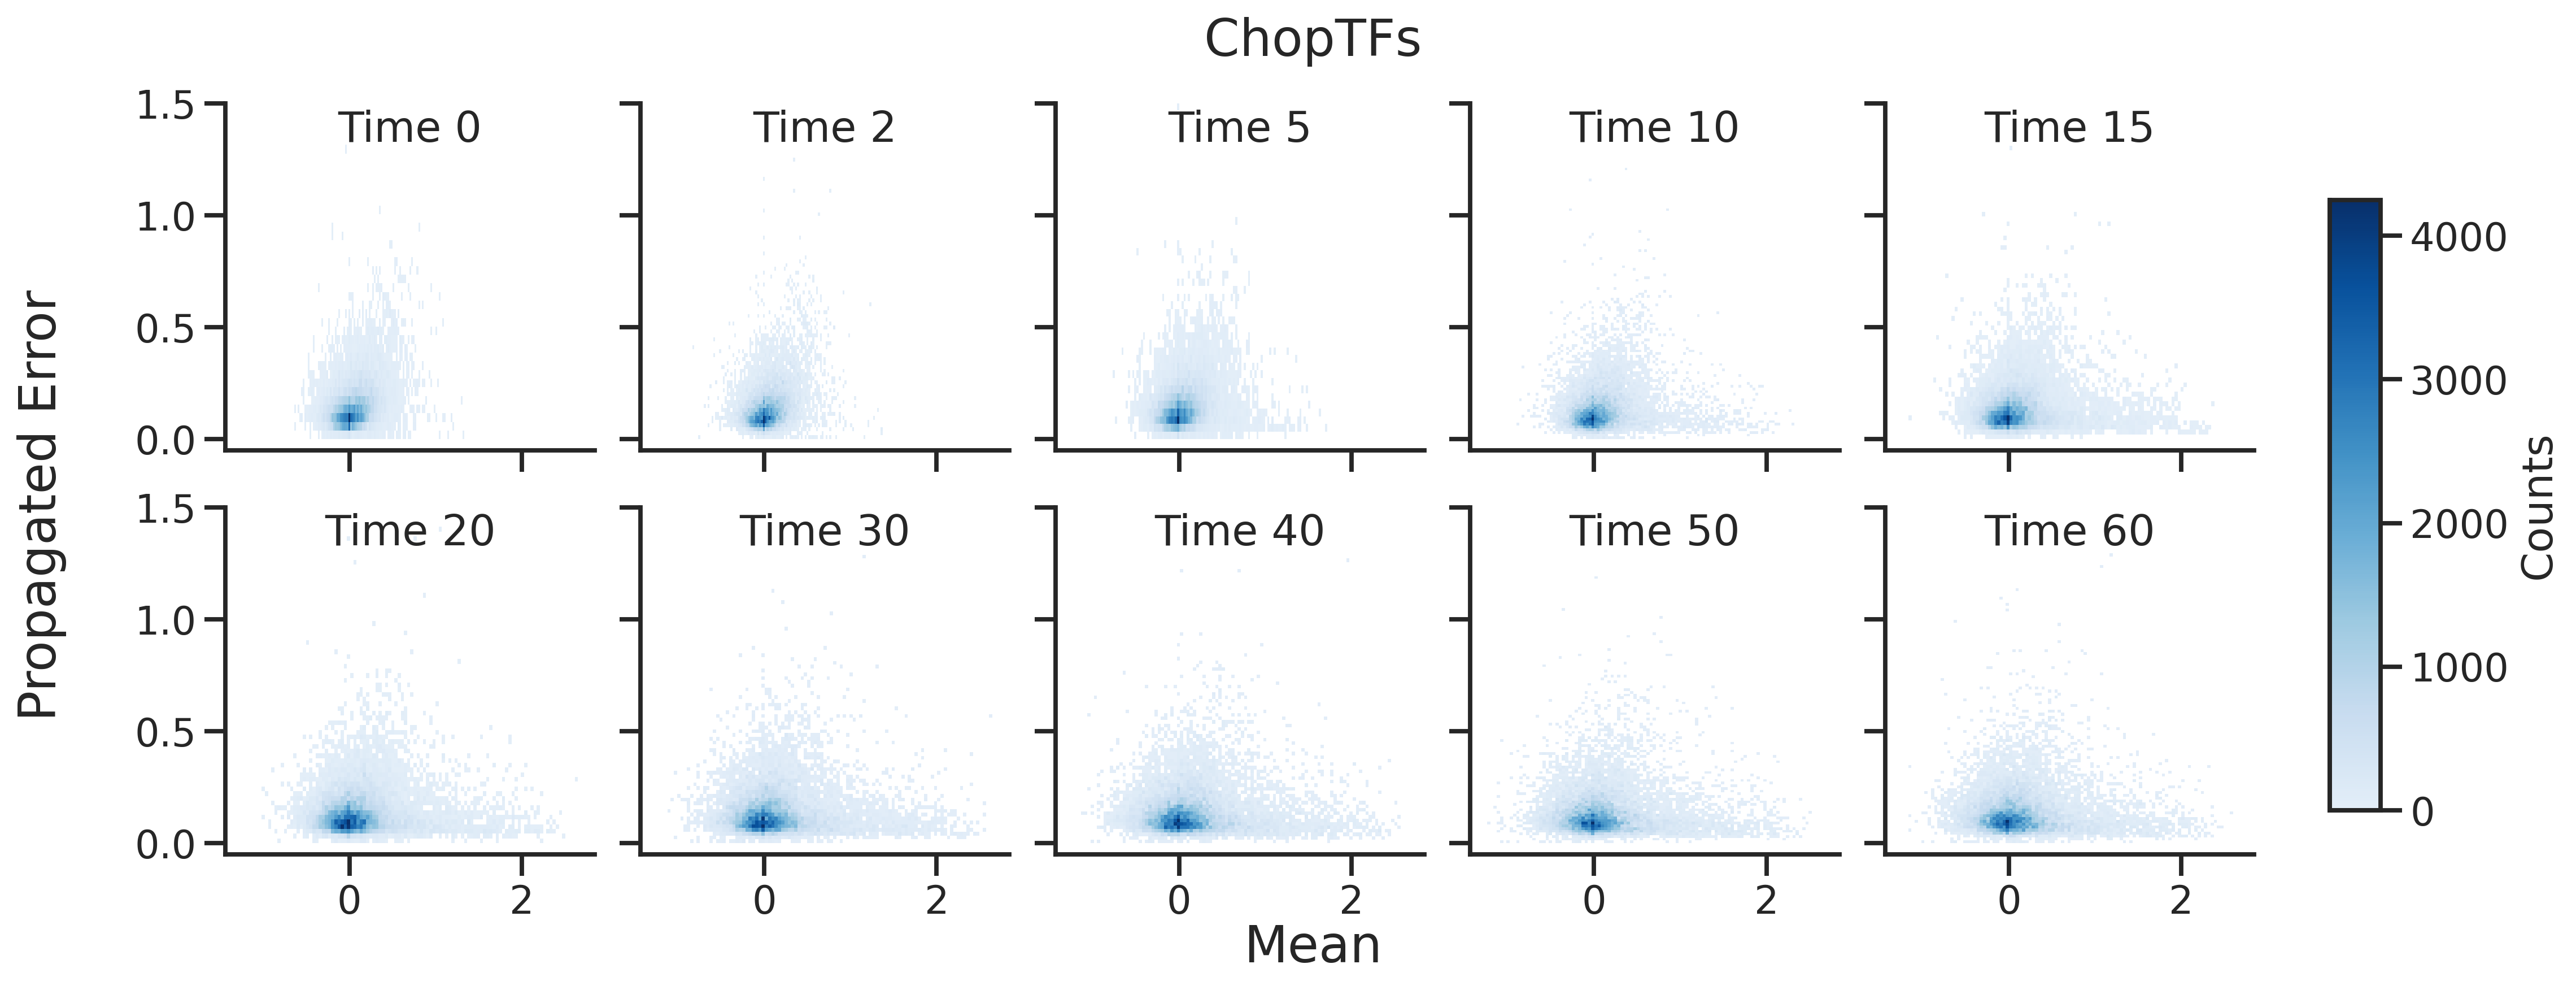

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

df = final_results.copy()

# --- Truncate colormap (same as yours) ---
def truncate_colormap(cmap, minval=0.15, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.1, 1.0)

# --- Global max for consistent color scaling ---
# Drop NaNs and infs for histogram calculation
clean = df[["grand_mean", "SE_final"]].replace([np.inf, -np.inf], np.nan).dropna()

counts, _, _ = np.histogram2d(clean["grand_mean"], clean["SE_final"], bins=80)
global_max = counts.max()
global_max = counts.max()

# --- Sort times ---
times = sorted(df["time"].unique())

# --- Layout ---
n = len(times)
cols = min(5, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows),
                         sharex=True, sharey=True, dpi=300)

axes = np.array(axes).reshape(-1)

# --- Global axis limits ---
xmin, xmax = df["grand_mean"].min(), df["grand_mean"].max()
ymin, ymax = df["SE_final"].min(), df["SE_final"].max()

xpad, ypad = 1, 1
ymin, ymax = ymin - ypad, ymax + ypad

# --- Plot ---
for i, time in enumerate(times):
    ax = axes[i]
    subset = df[df["time"] == time]

    sns.histplot(
        data=subset,
        x="grand_mean",
        y="SE_final",
        bins=100,
        cmap=cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(f"Time {time}", y=0.85)
    # ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.05,1.5)
    ax.set_xlabel("")
    ax.set_ylabel("")

# --- Turn off unused axes ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# --- Shared labels ---
fig.supxlabel("Mean", y=0.04)
fig.supylabel("Propagated Error", x = -0.01)

# --- Shared colorbar ---
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=global_max),
    cmap=cmap
)
sm.set_array([])

cbar_ax = fig.add_axes([0.9, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cbar_ax, label="Counts")
fig.suptitle("ChopTFs")

# --- Layout polish ---
plt.tight_layout(rect=[0, 0, 0.88, 1], pad = 0.5)
sns.despine()
plt.show()

# Plotting controls

In [41]:
chopTF_controls = pd.read_csv("../../../data/chopTFs_controls.csv", index_col = 0)
chopTF_controls

,ADseq,Name,group
59,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2
65,TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA,CITED2_ARO2A_0,CITED2
63,TDFIDEEVAMSAVIEMGADRIKEAPEAWAGQNEFDFMTDF,CITED2_L2A_0,CITED2
61,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,CITED2_L2I_0,CITED2
67,TDAIDEEVAMSAVIEMGADRIKEAPEAAAGQNEADAMTDA,CITED2_LWF2A_0,CITED2
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,GCN4_CAAD
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,GCN4_CAAD
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,GCN4_CAAD
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,GCN4_CAAD
21,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,GCN4alt_0,GCN4_altCAAD


In [51]:
gal4_tile = "STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK"
gal4_tile_data = dbd_norm_activities[dbd_norm_activities["ADseq"] == gal4_tile]
gal4_tile_data

,ADseq,AD_end,AD_BC,RPTR_BC,time,rep,shifted_activity
30301,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTAATTACCGA,TGACTGCTGTTTAC,0,2,-0.117741
30302,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,GCCTCCGCCCA,TGCTTCCCAACGTG,0,2,0.166444
30303,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TCATGGAAGAA,TTAGAGTAAAGTGT,0,2,0.205953
30304,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TGTAGGTGCCC,AAAAATTGCGTAAT,0,2,0.205953
72140,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTAATTACCGA,TGACTGCTGTTTAC,2,2,-0.301254
...,...,...,...,...,...,...,...
1302383,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TGTAGGTGCCC,AAAAATTGCGTAAT,50,4,1.284880
1350302,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTAATTACCGA,TGACTGCTGTTTAC,60,4,1.229166
1350303,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,GCCTCCGCCCA,TGCTTCCCAACGTG,60,4,1.181216
1350304,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TCATGGAAGAA,TTAGAGTAAAGTGT,60,4,1.933813


In [52]:
gal4_tile_data_t15 = gal4_tile_data[gal4_tile_data["time"] == 20]
gal4_tile_data_t15

,ADseq,AD_end,AD_BC,RPTR_BC,time,rep,shifted_activity
250993,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTAATTACCGA,TGACTGCTGTTTAC,20,2,1.287500
250994,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTACCTGCCTT,TTGAGCCTTGTCTA,20,2,0.851772
250995,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,GCCTCCGCCCA,TGCTTCCCAACGTG,20,2,1.187798
250996,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TCATGGAAGAA,TTAGAGTAAAGTGT,20,2,1.602771
250997,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TGTAGGTGCCC,AAAAATTGCGTAAT,20,2,1.134890
711563,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CATTAGCGACA,GTGGAACTTTACAA,20,3,0.307442
711564,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTAATTACCGA,TGACTGCTGTTTAC,20,3,1.248719
711565,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,CTACCTGCCTT,TTGAGCCTTGTCTA,20,3,1.328631
711566,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,GCCTCCGCCCA,TGCTTCCCAACGTG,20,3,1.513368
711567,STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK,TATTCCAGTTACTACTGATGATGTTTCTCCAGCTGATAAA,TCATGGAAGAA,TTAGAGTAAAGTGT,20,3,1.702893


(0.0, 1.7726654990267978)

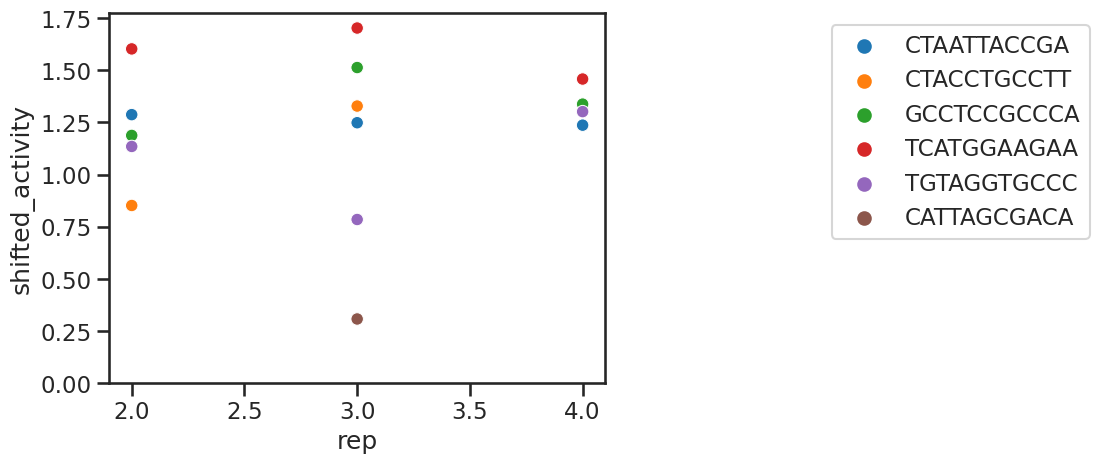

In [53]:
sns.scatterplot(data = gal4_tile_data_t15, x = "rep", y = "shifted_activity", hue = "AD_BC")
plt.legend(loc  = 'upper right', bbox_to_anchor = (2,1))
plt.ylim(0,None)

(0.0, 1.7726654990267978)

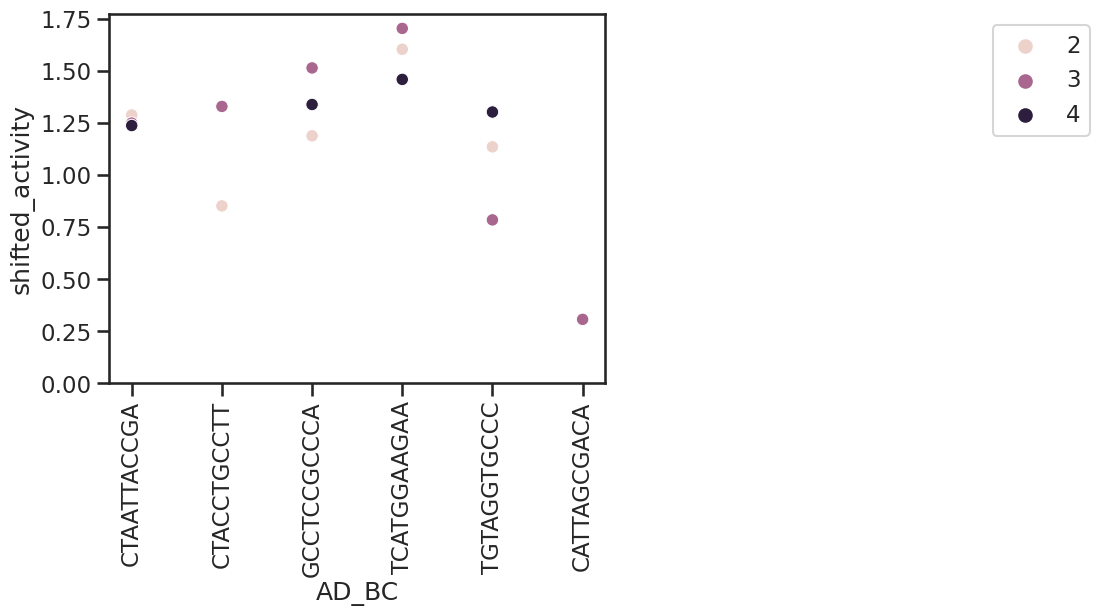

In [54]:
sns.scatterplot(data = gal4_tile_data_t15, x = "AD_BC", y = "shifted_activity", hue = "rep")
plt.legend(loc  = 'upper right', bbox_to_anchor = (2,1))
plt.xticks(rotation = 90)
plt.ylim(0,None)

In [46]:
bio_tech_rep_err_mult_meas

NameError: name 'bio_tech_rep_err_mult_meas' is not defined

In [173]:
bio_tech_rep_err_mult_meas_controls = pd.merge(chopTF_controls, bio_tech_rep_err_mult_meas)
bio_tech_rep_err_mult_meas_controls

,ADseq,Name,group,AD_end,time,grand_mean,s_bio,n_bio,SE_tech_sq_mean,SE_final
0,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,0,0.310576,0.258209,8,0.028061,0.108819
1,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,2,0.369249,0.244408,7,0.013796,0.102491
2,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,5,0.972586,0.131542,8,0.016288,0.064799
3,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,10,1.791287,0.163896,9,0.003744,0.058315
4,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,15,1.965983,0.117350,8,0.014168,0.059097
...,...,...,...,...,...,...,...,...,...,...
534,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,20,2.233061,0.230957,14,0.005365,0.064755
535,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,30,2.283866,0.153220,14,0.007110,0.046741
536,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,40,2.318195,0.243553,14,0.015302,0.073007
537,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,50,2.146650,0.252445,14,0.017081,0.075974


<Axes: xlabel='n_bio', ylabel='Count'>

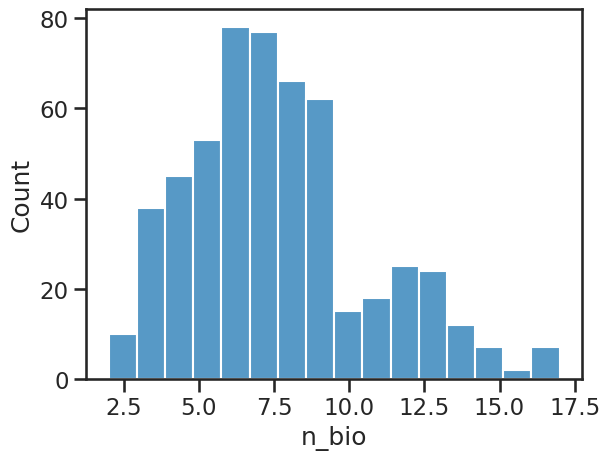

In [174]:
# The control tiles have many bio reps
sns.histplot(bio_tech_rep_err_mult_meas_controls["n_bio"])

In [175]:
tech_rep_err_controls = pd.merge(chopTF_controls, tech_rep_err).dropna()
tech_rep_err_controls

,ADseq,Name,group,AD_end,AD_BC,RPTR_BC,time,mean,std,count,SE_tech,SE_tech_sq
1,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,AATGTTTATCA,TCTGTTAATTATAT,5,0.850686,0.243572,3,0.140626,0.019776
3,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,AATGTTTATCA,TCTGTTAATTATAT,15,1.908745,0.456391,3,0.263497,0.069431
4,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,AATGTTTATCA,TCTGTTAATTATAT,20,1.760720,0.392001,2,0.277187,0.076832
5,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,AATGTTTATCA,TCTGTTAATTATAT,30,2.335900,0.238760,3,0.137848,0.019002
6,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,GTGGTTGGGTCAGAATGAATTTGACTTTATGACTGACTTT,AATGTTTATCA,TCTGTTAATTATAT,40,1.906914,0.420630,2,0.297430,0.088465
...,...,...,...,...,...,...,...,...,...,...,...,...
4052,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,TTTAGGAAGTA,GTATACCATCGGTA,20,2.960550,0.107656,3,0.062155,0.003863
4053,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,TTTAGGAAGTA,GTATACCATCGGTA,30,2.697629,0.095461,2,0.067501,0.004556
4054,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,TTTAGGAAGTA,GTATACCATCGGTA,40,2.845248,0.331061,3,0.191138,0.036534
4055,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1,GAATGATGAGTTCTGGACTGATTTGTTTATGAATGATATT,TTTAGGAAGTA,GTATACCATCGGTA,50,2.566323,0.070992,3,0.040987,0.001680


In [1]:
# tech_rep_err_controls = tech_rep_err_controls[tech_rep_err_controls["count"] == 3]
# tech_rep_err_controls

In [2]:
plot_configs = [
    {"df": bio_tech_rep_err_mult_meas_controls, "y_mean": "grand_mean", "y_std": "SE_final", "title": ""},
]

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks')
sns.set_context('talk')

# Only one config
cfg = plot_configs[0]

for group_name in cfg["df"]["group"].unique():
    
    # Filter for group
    sub = cfg["df"][cfg["df"]["group"] == group_name].copy()
    
    # Figure
    fig, ax = plt.subplots(figsize=(7,5), dpi=300)
    
    # Palette by ADseq
    palette = sns.color_palette("tab10", n_colors=sub["ADseq"].nunique())
    
    handles = []
    labels = []
    
    for i, (adseq, subdf) in enumerate(sub.groupby("ADseq")):
        subdf = subdf.sort_values("time")
        label = subdf["Name"].iloc[0]
        
        x = subdf["time"]
        y = subdf[cfg["y_mean"]]
        yerr = subdf[cfg["y_std"]]
        color = palette[i]
        
        line, = ax.plot(x, y, color=color, label=label, marker='o', markersize=4)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)
        
        if label not in labels:
            handles.append(line)
            labels.append(label)
    
    # Labels and title
    ax.set_xlabel("Time")
    ax.set_ylabel("Normalized Activity")
    ax.set_title(group_name)
    
    # Legend outside
    fig.legend(handles, [_[:30] for _ in labels], 
               bbox_to_anchor=(1.05, 1), loc="upper left", fontsize='small', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

NameError: name 'bio_tech_rep_err_mult_meas_controls' is not defined

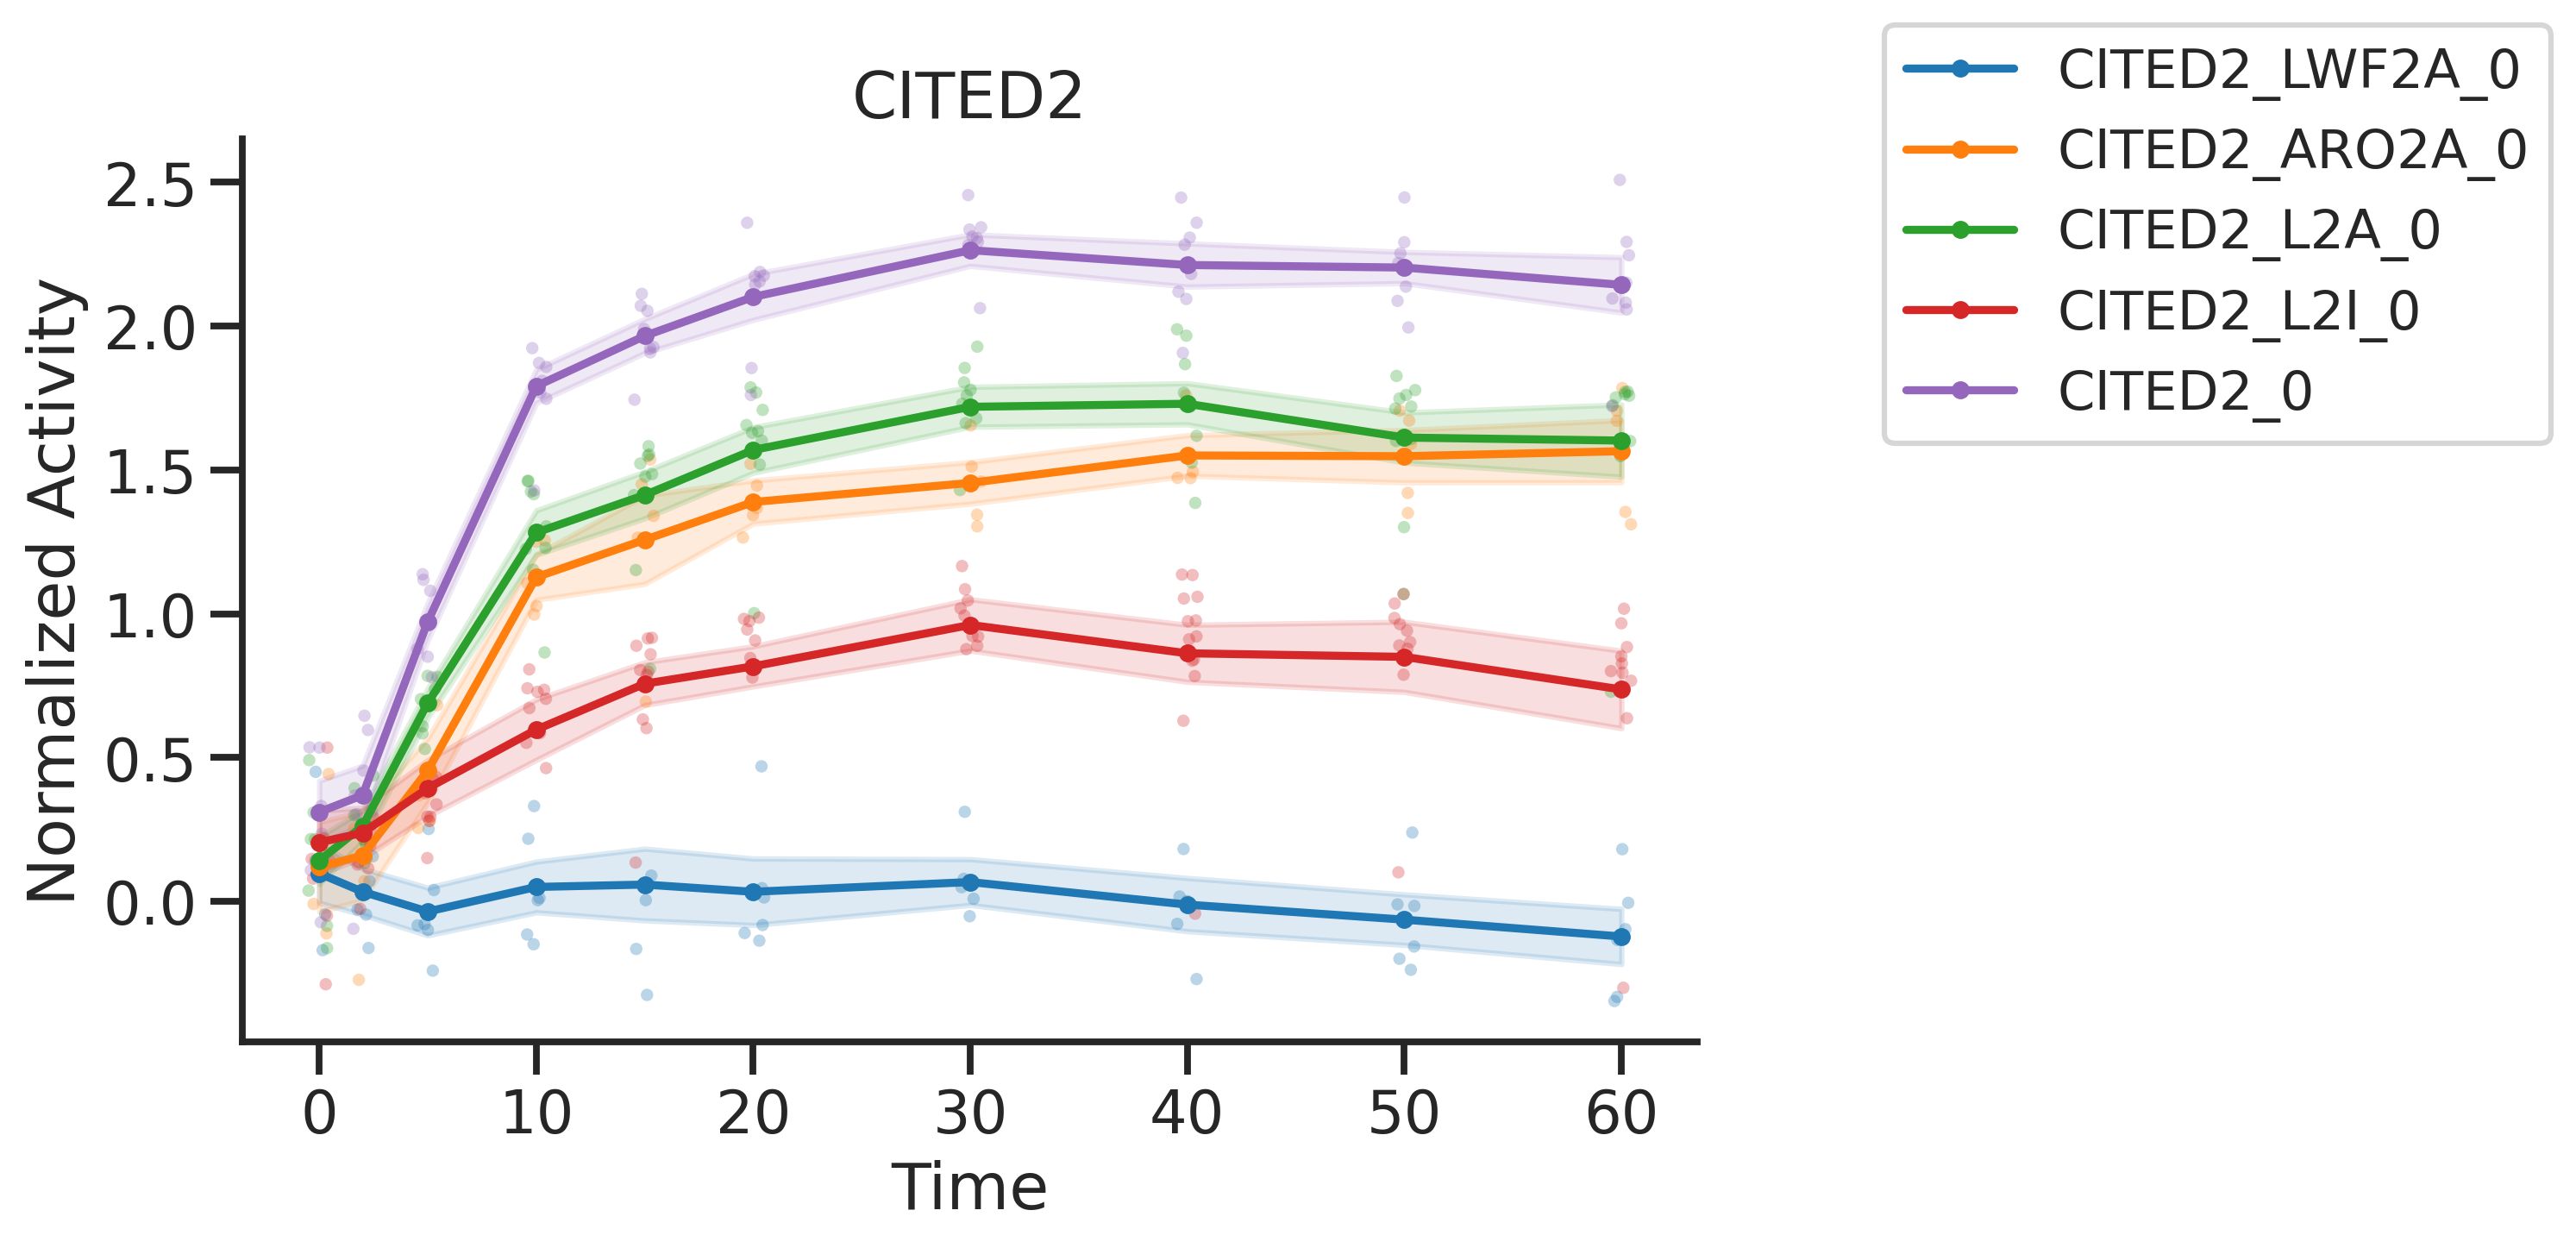

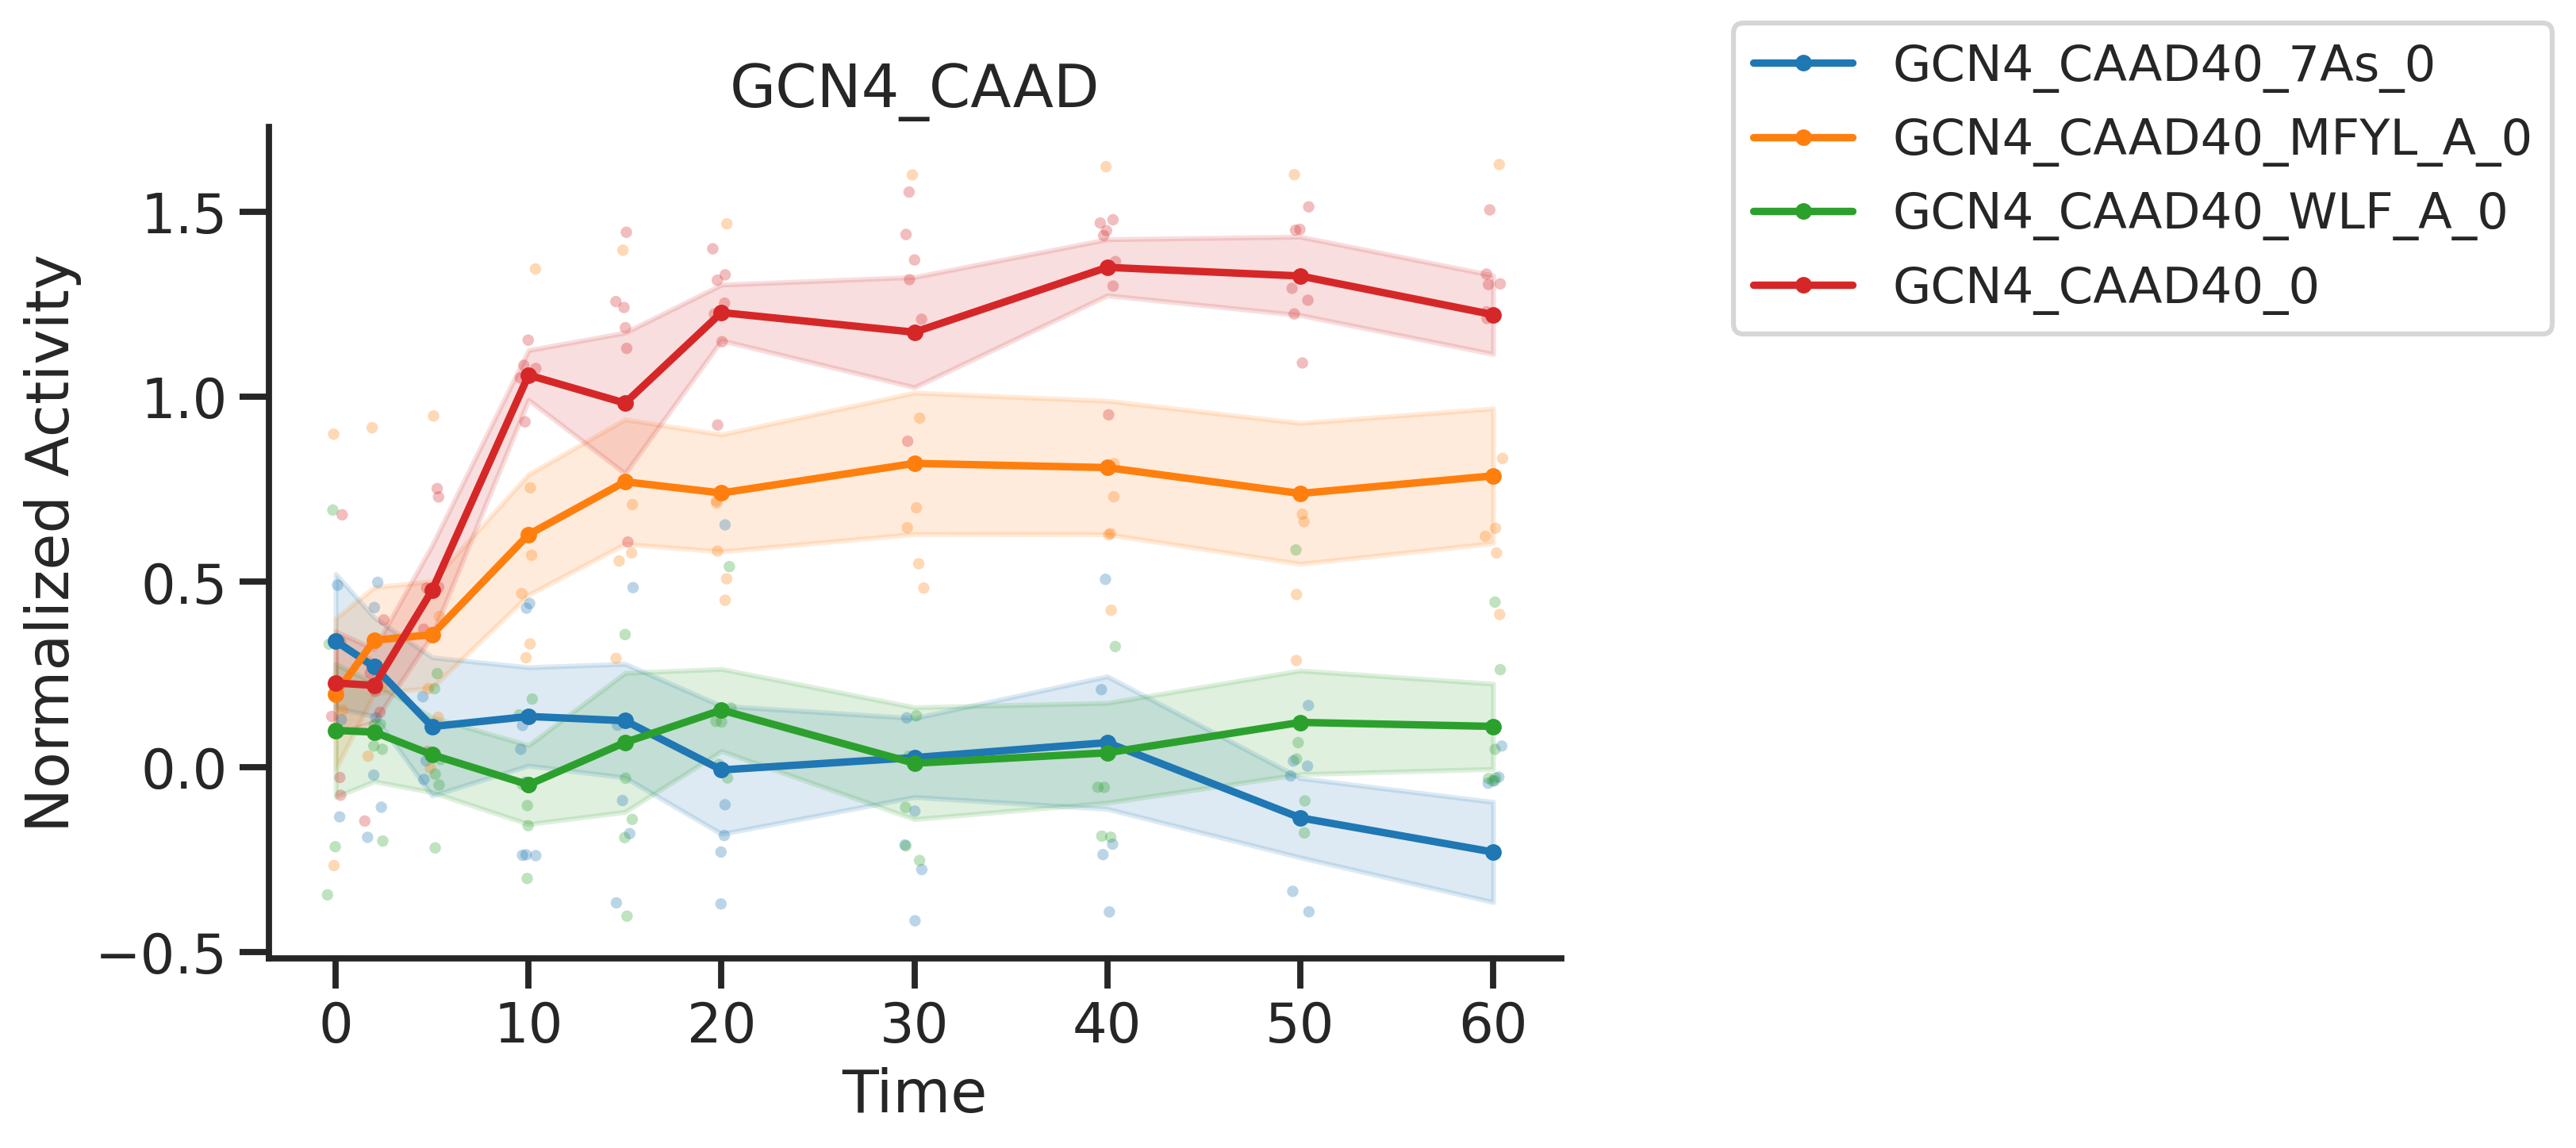

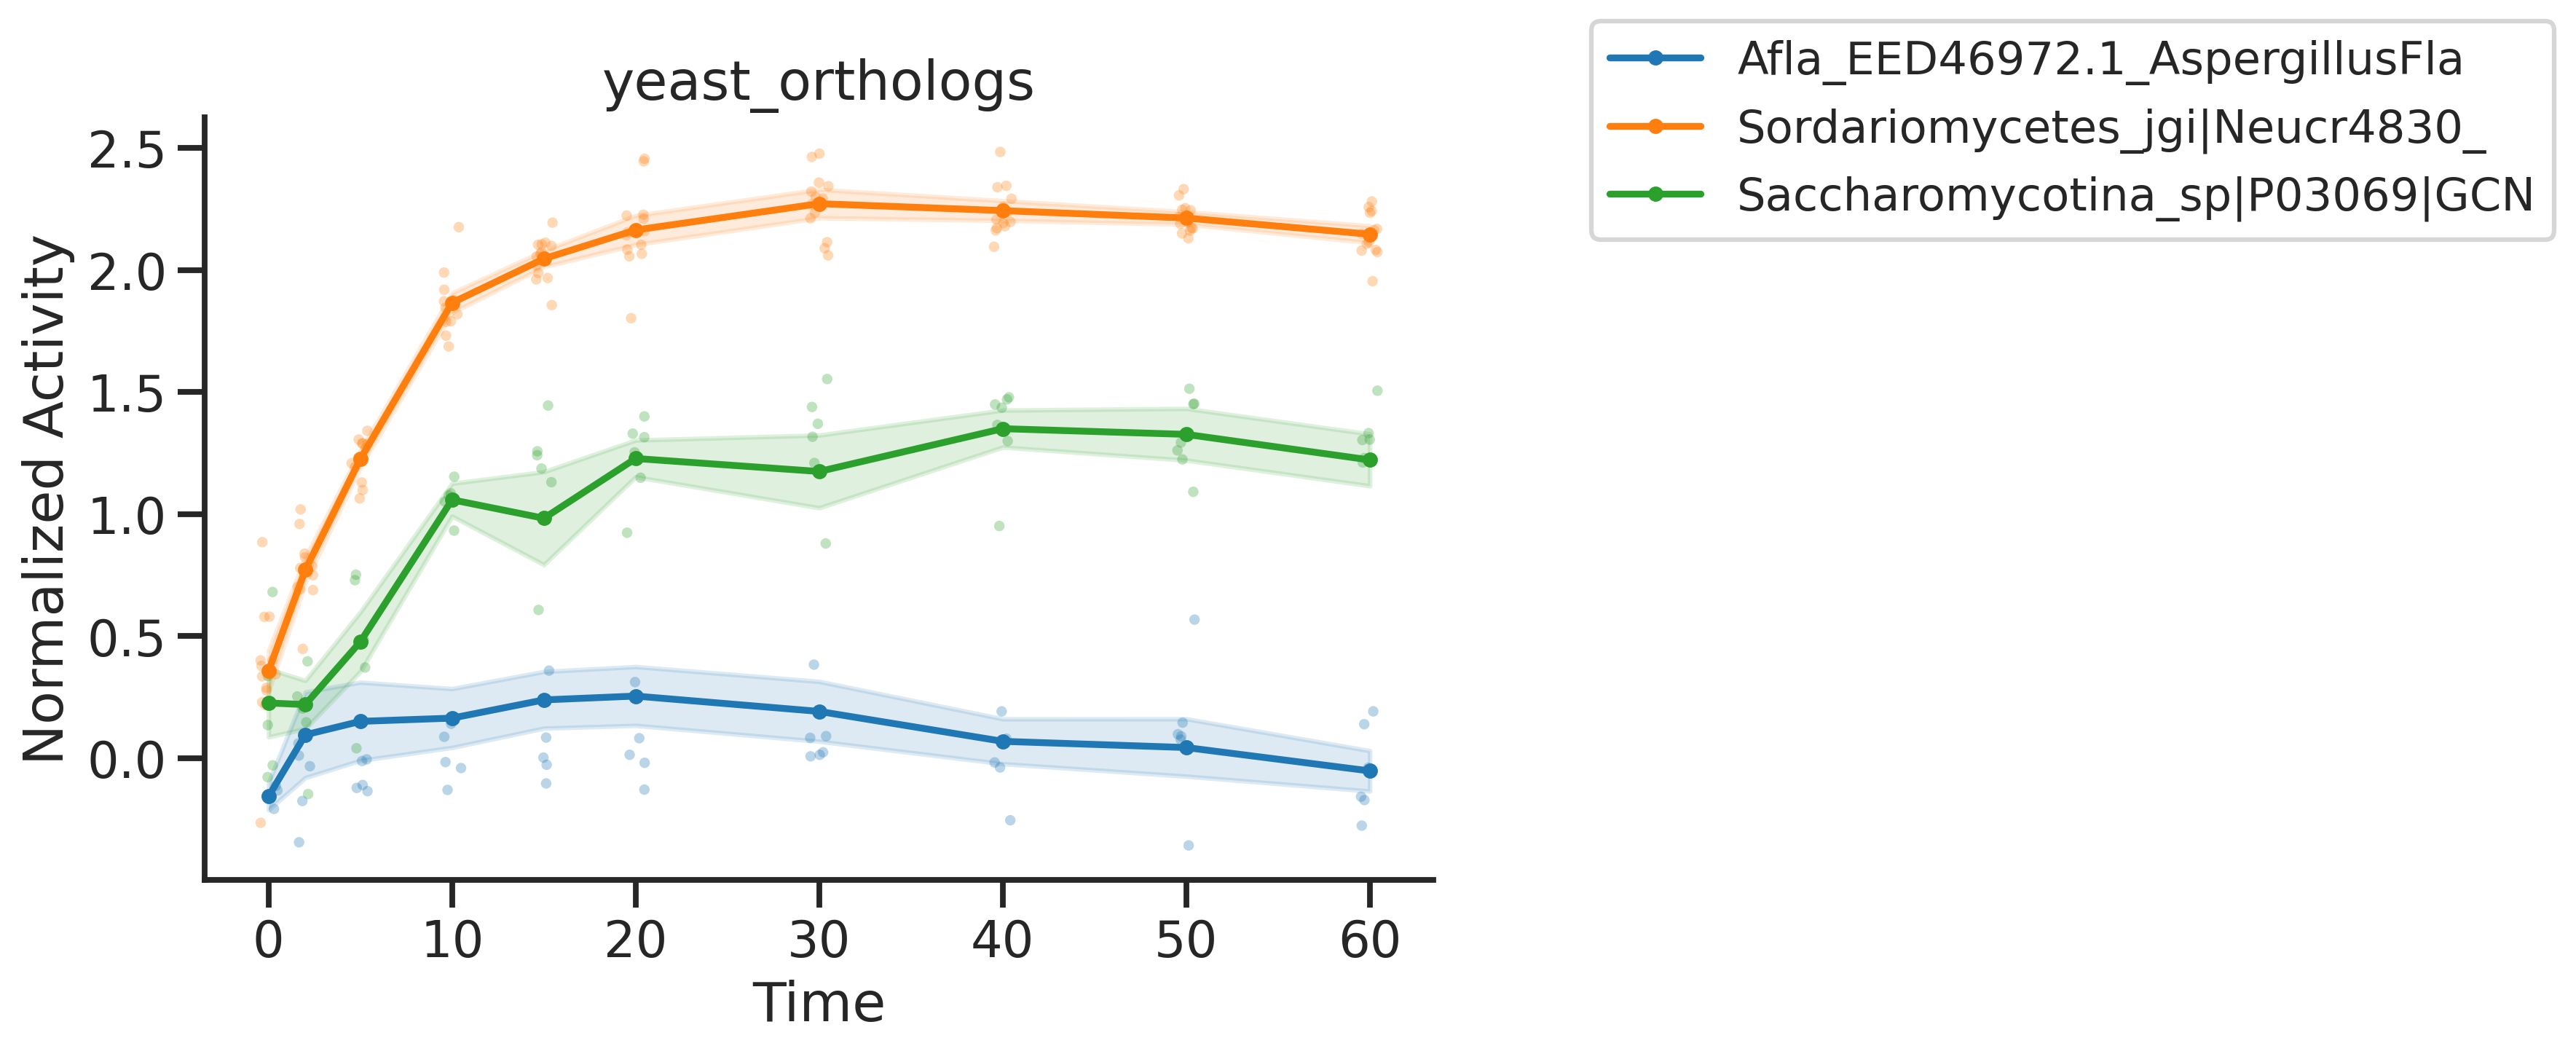

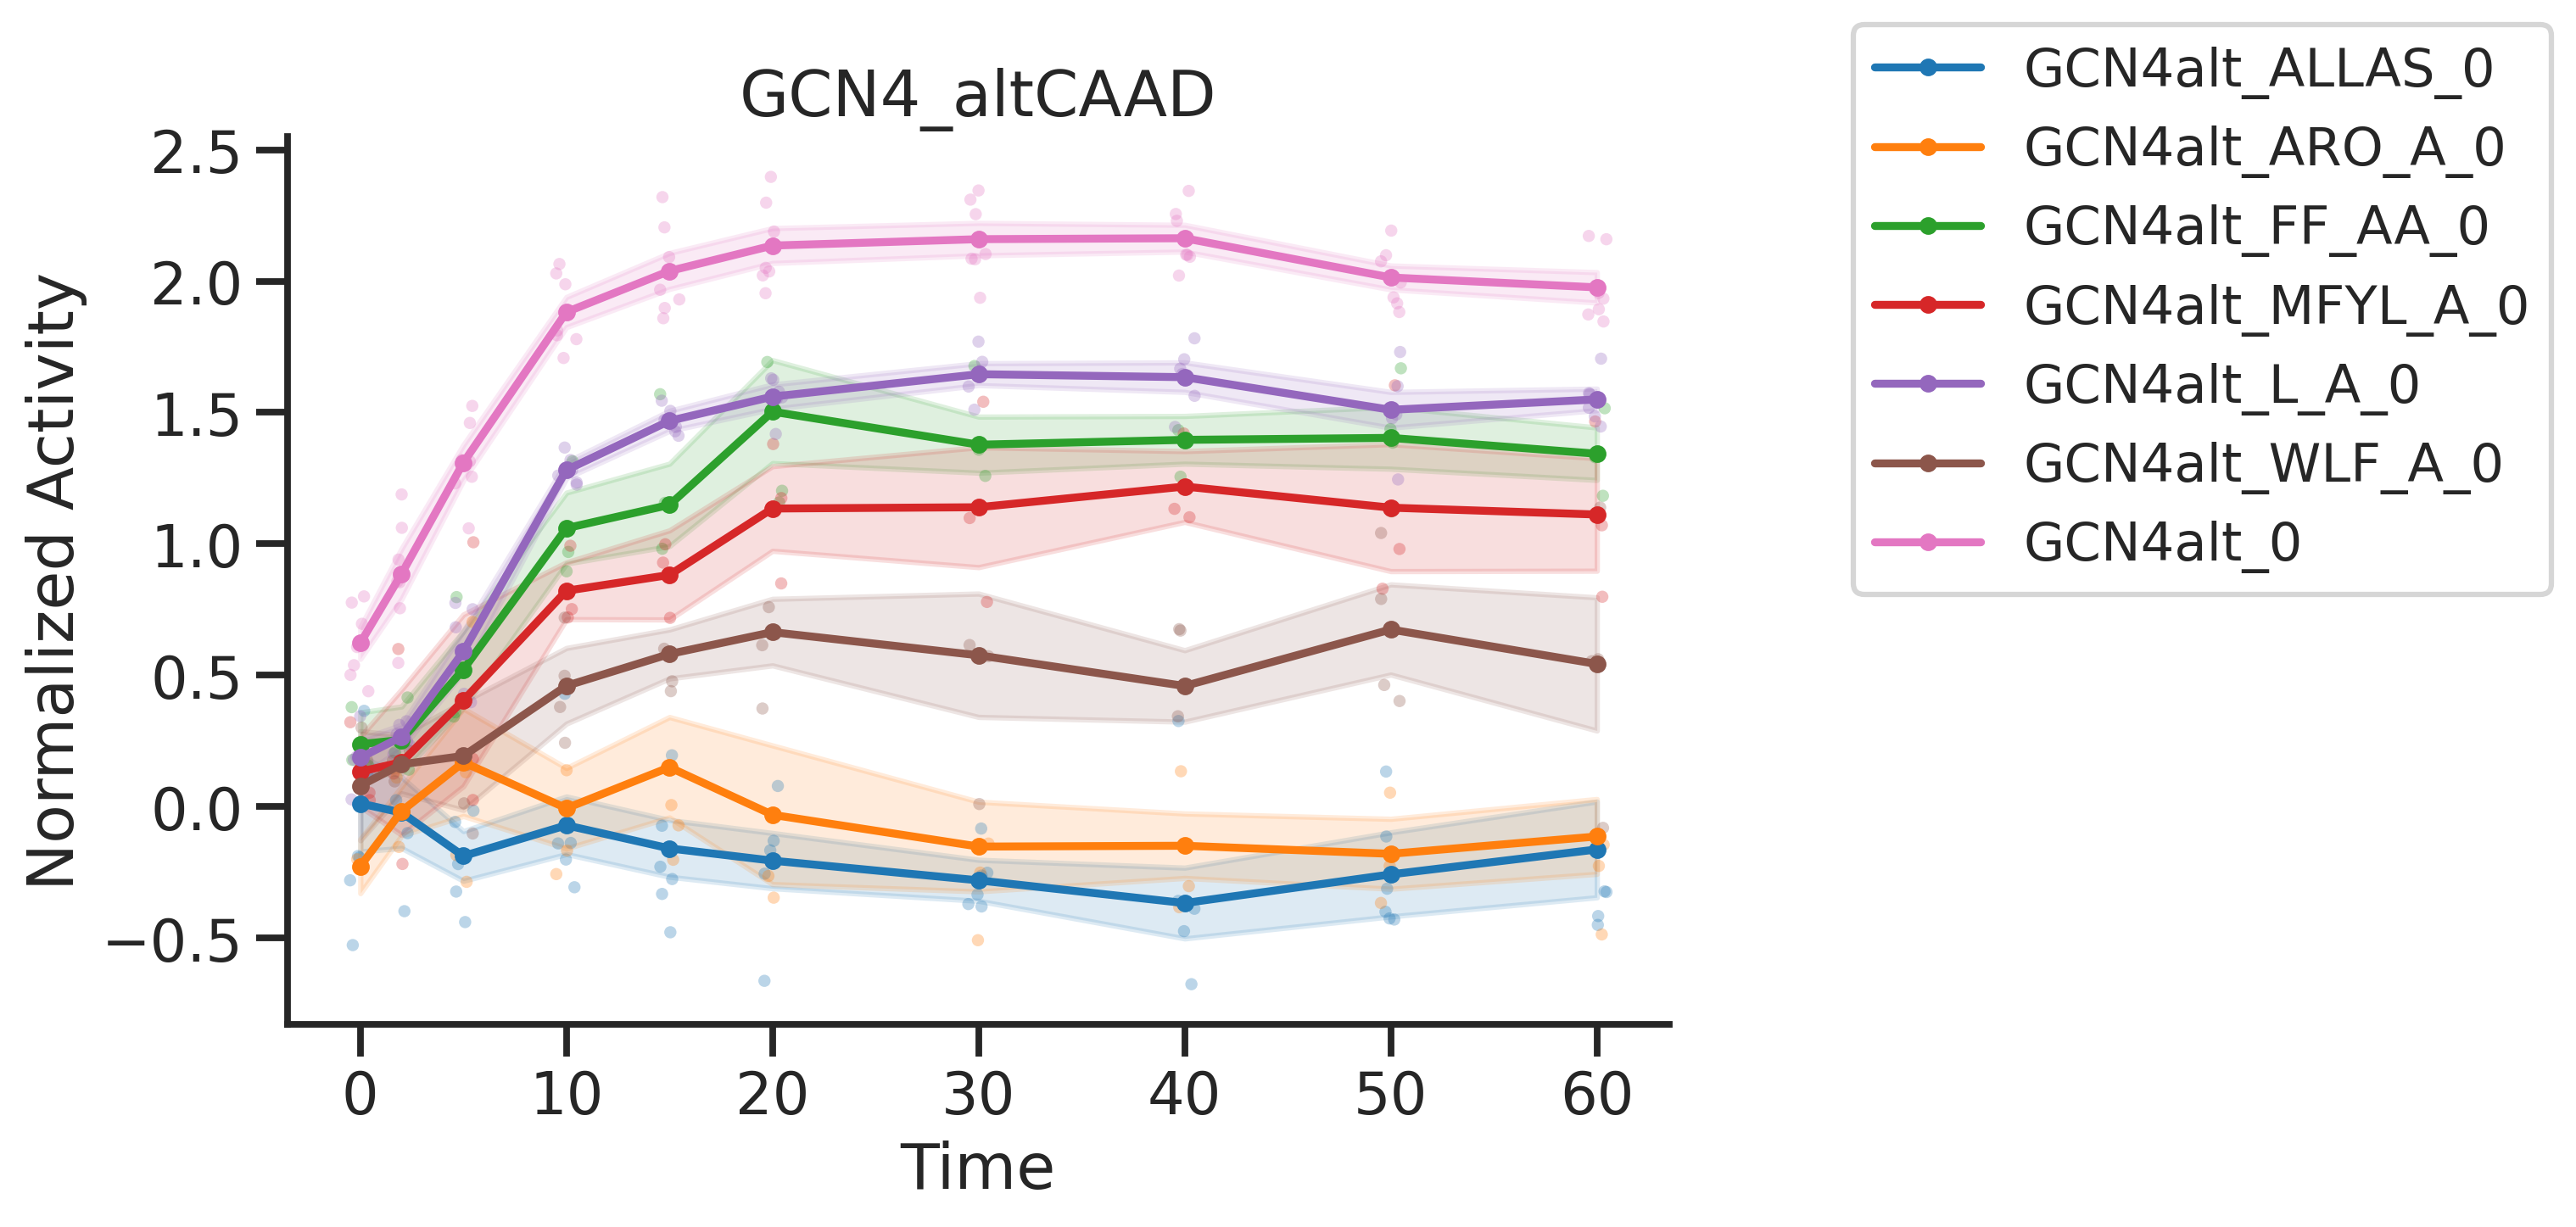

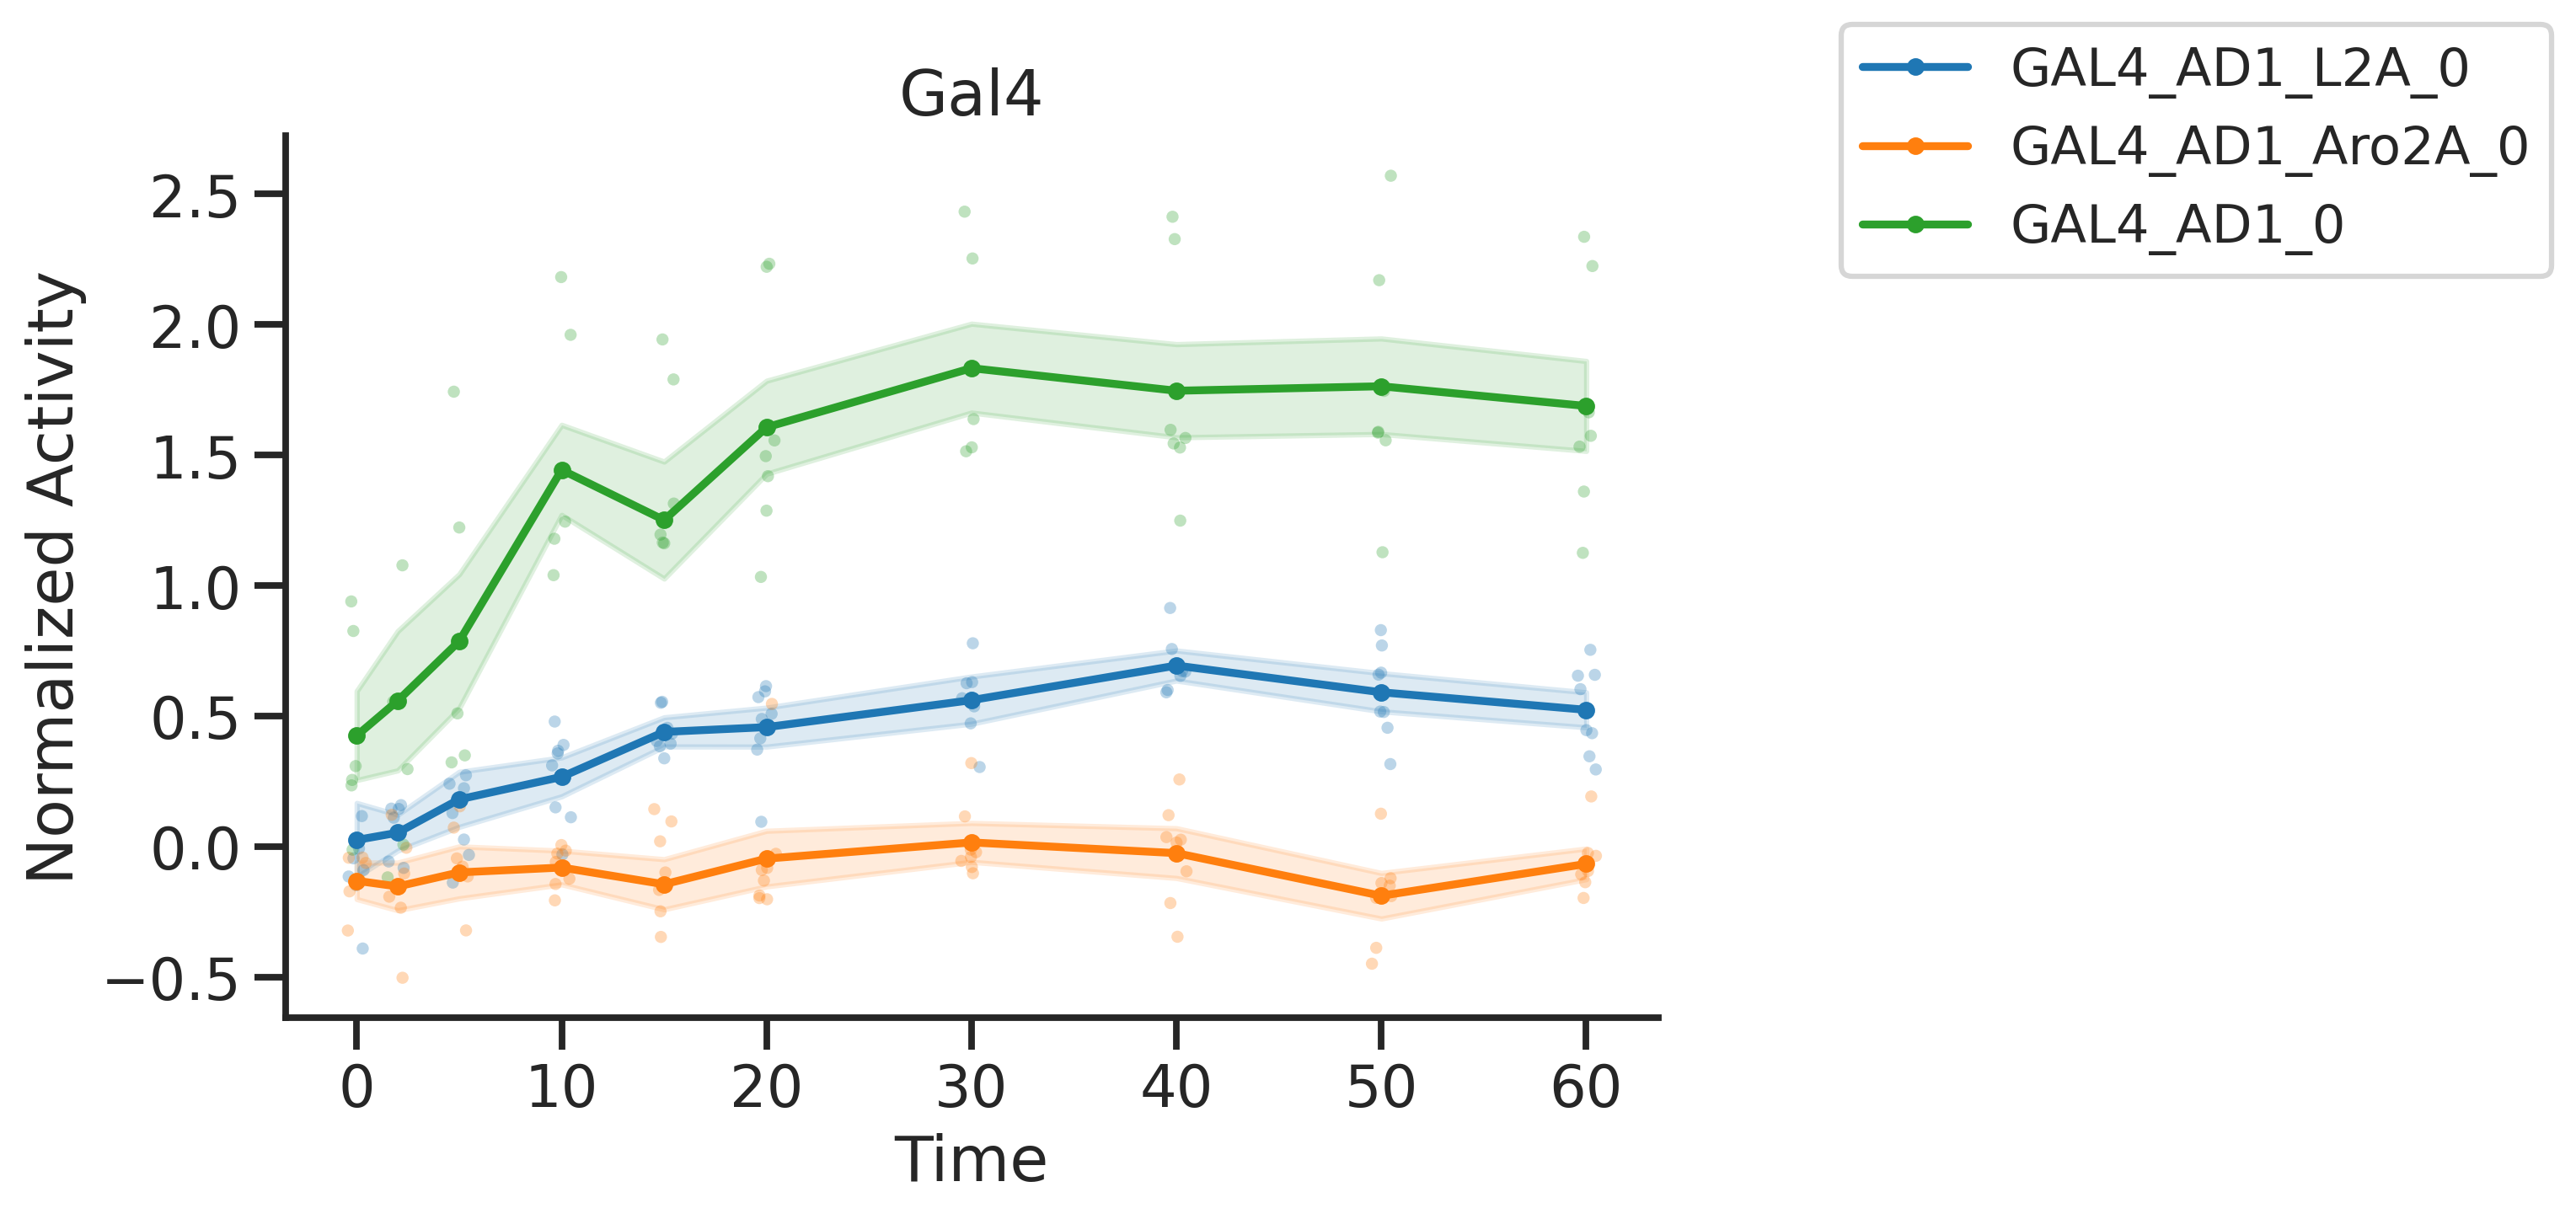

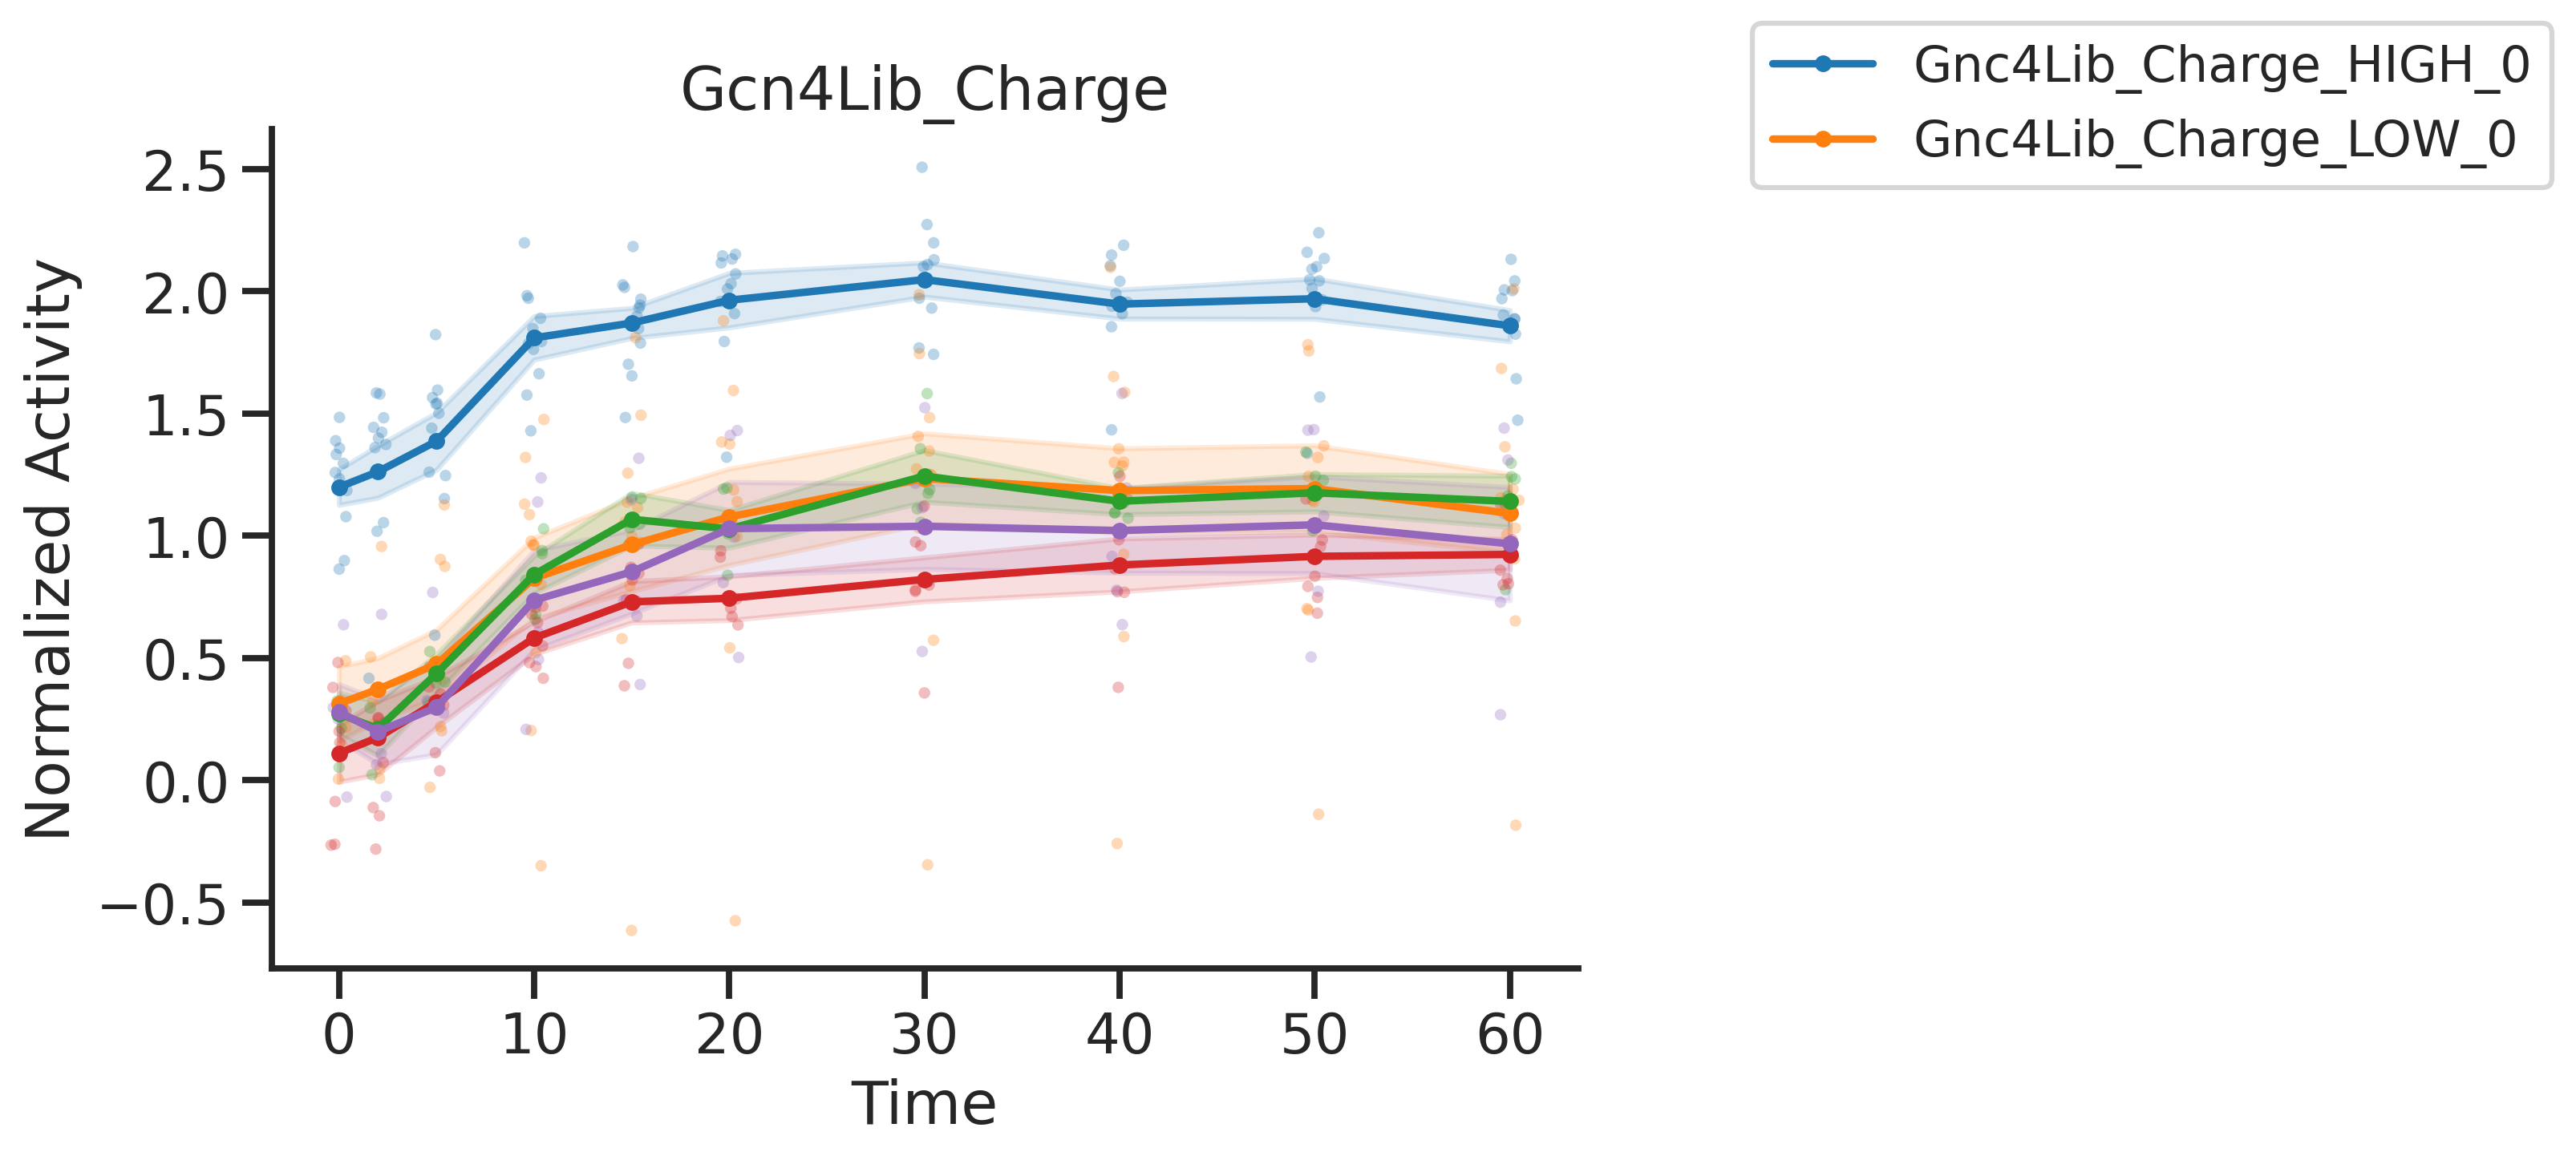

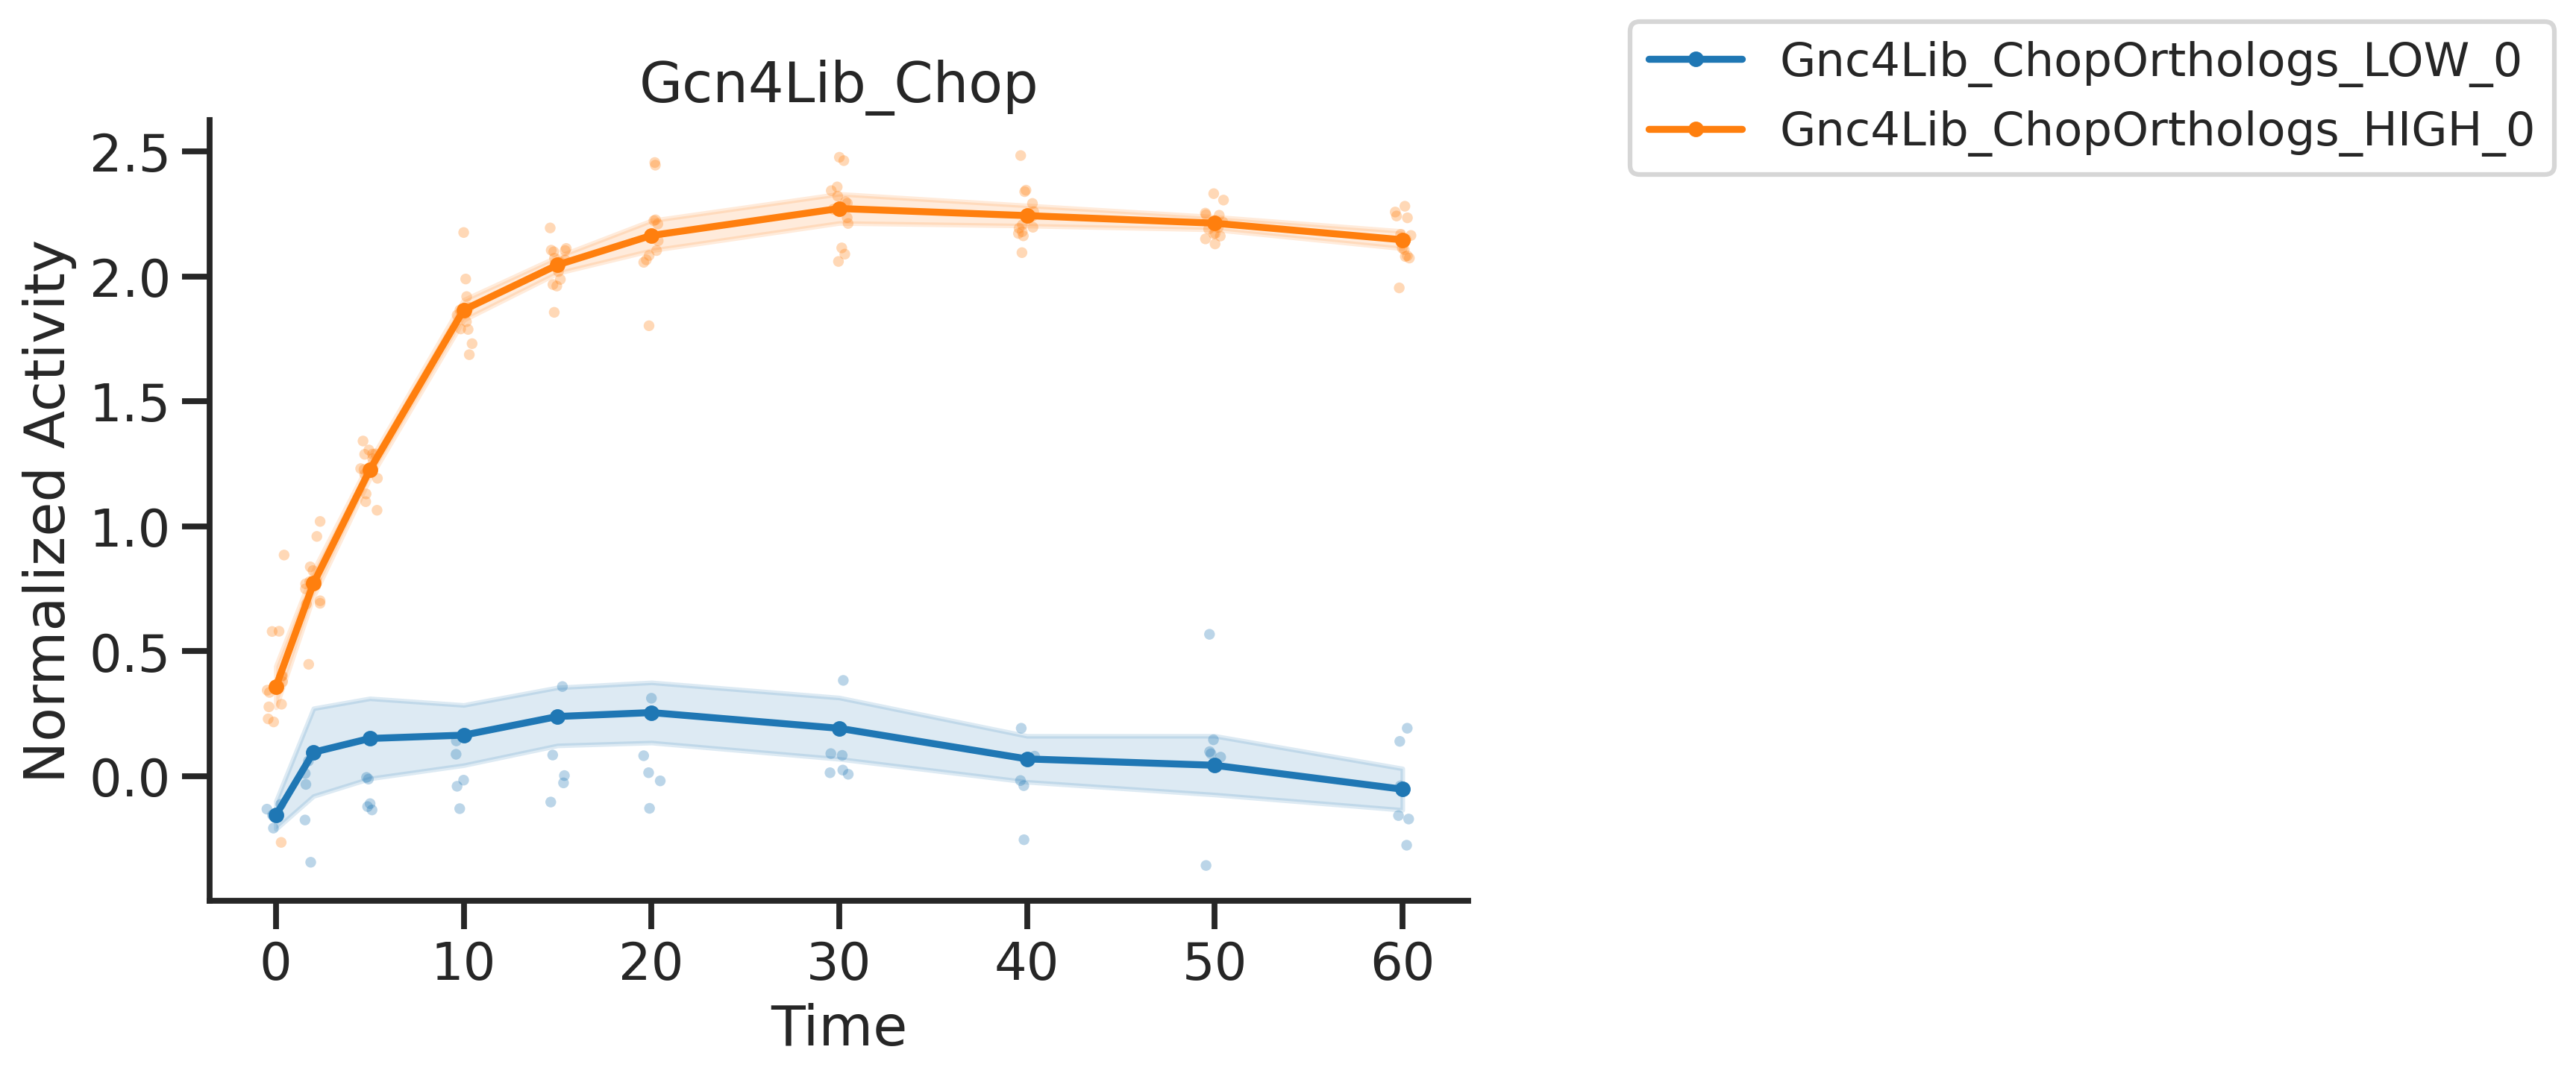

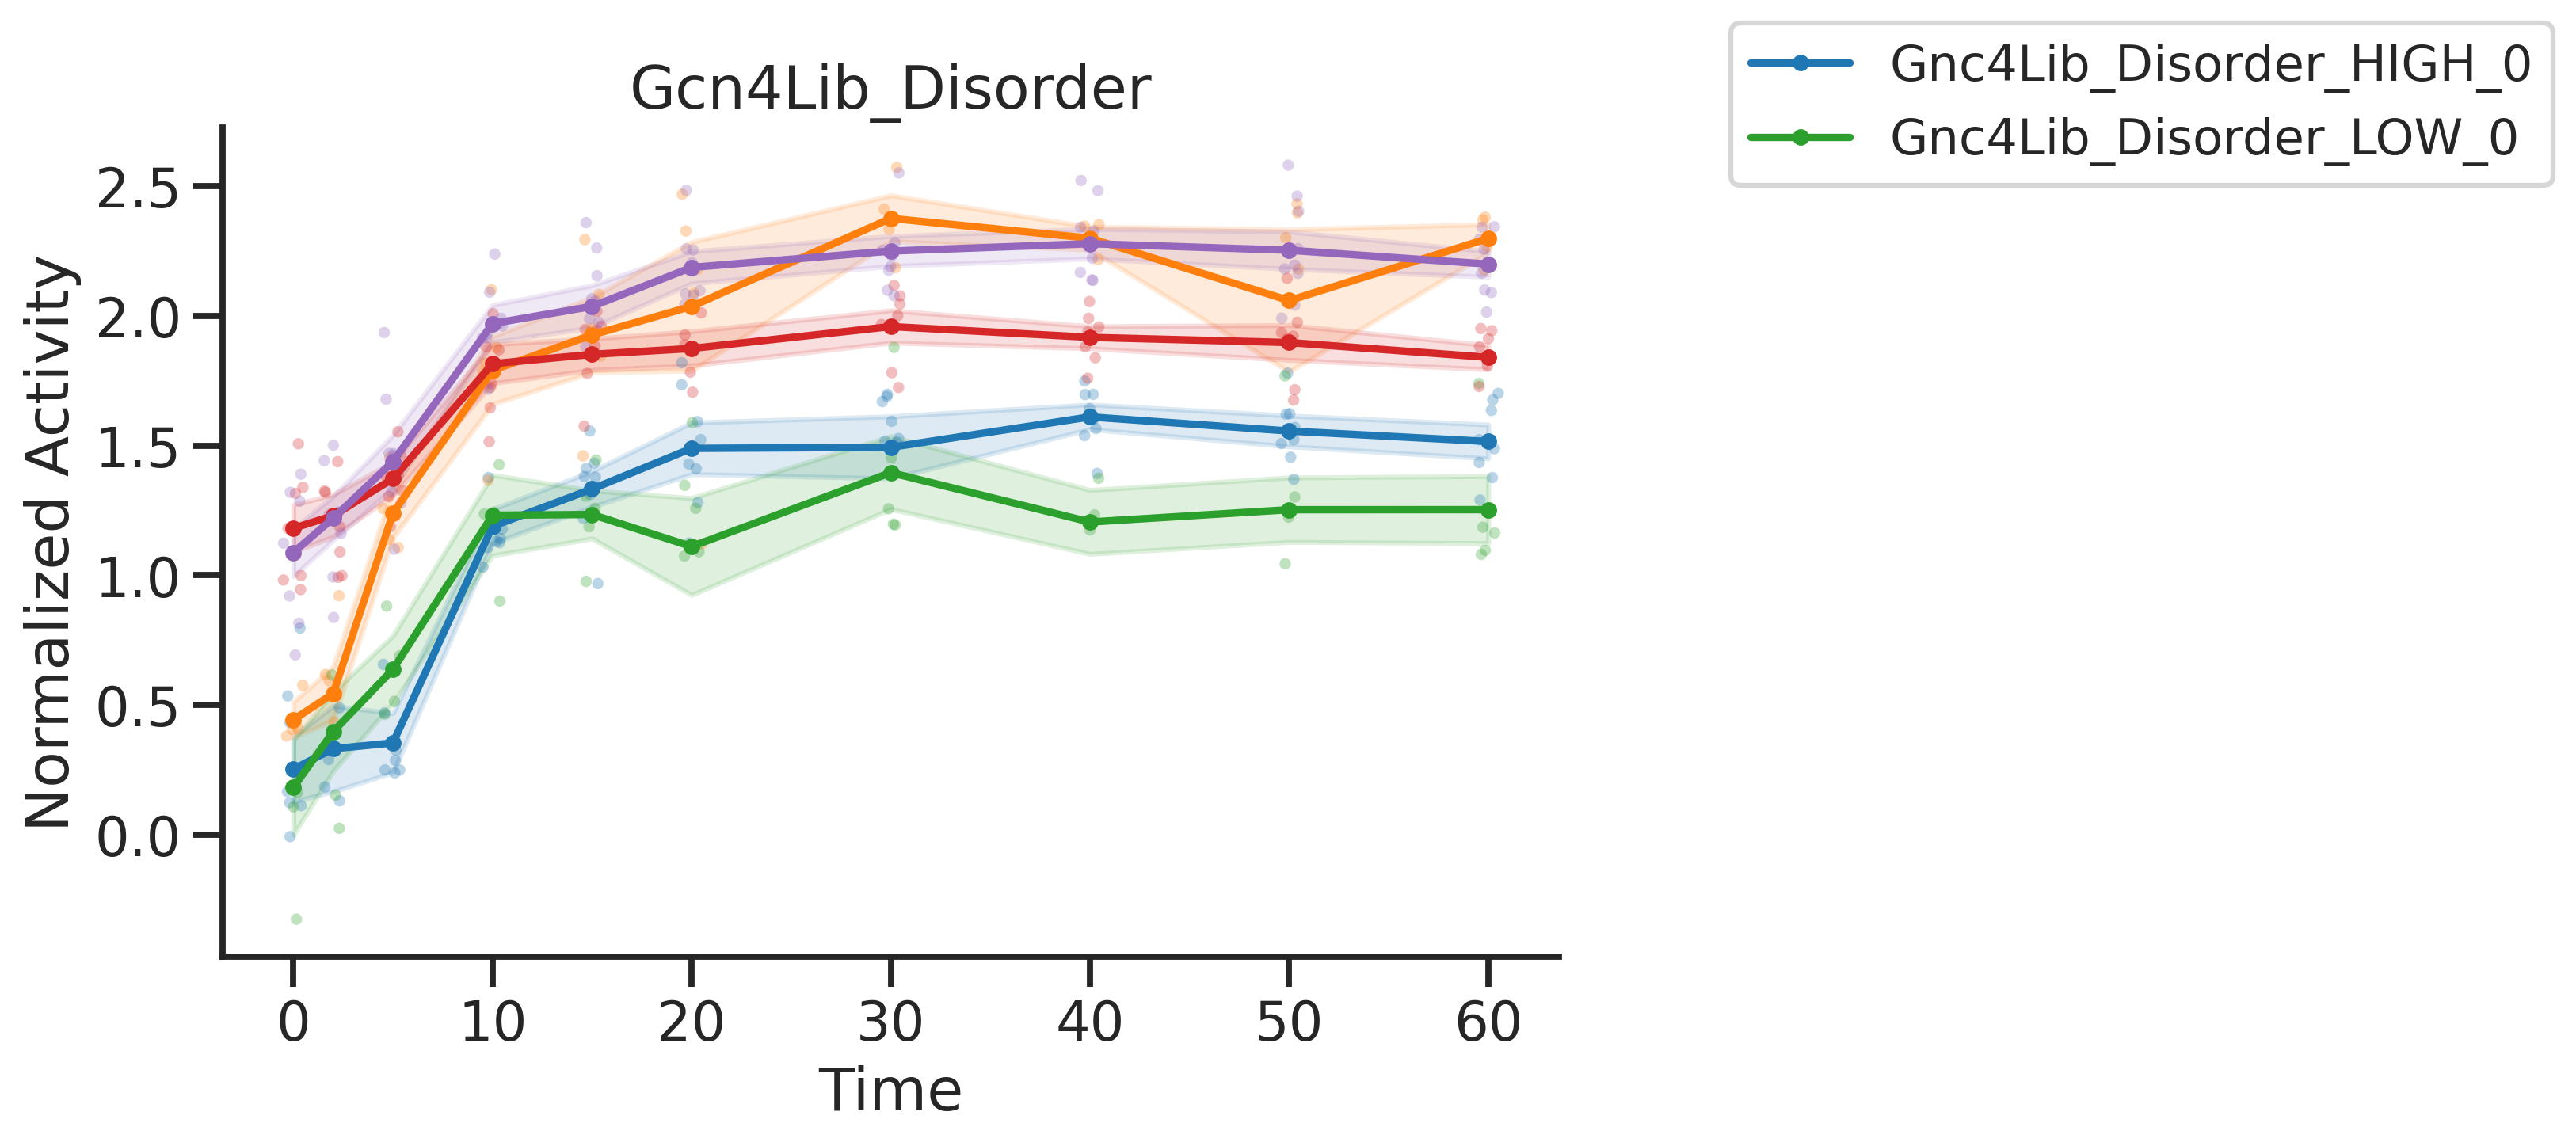

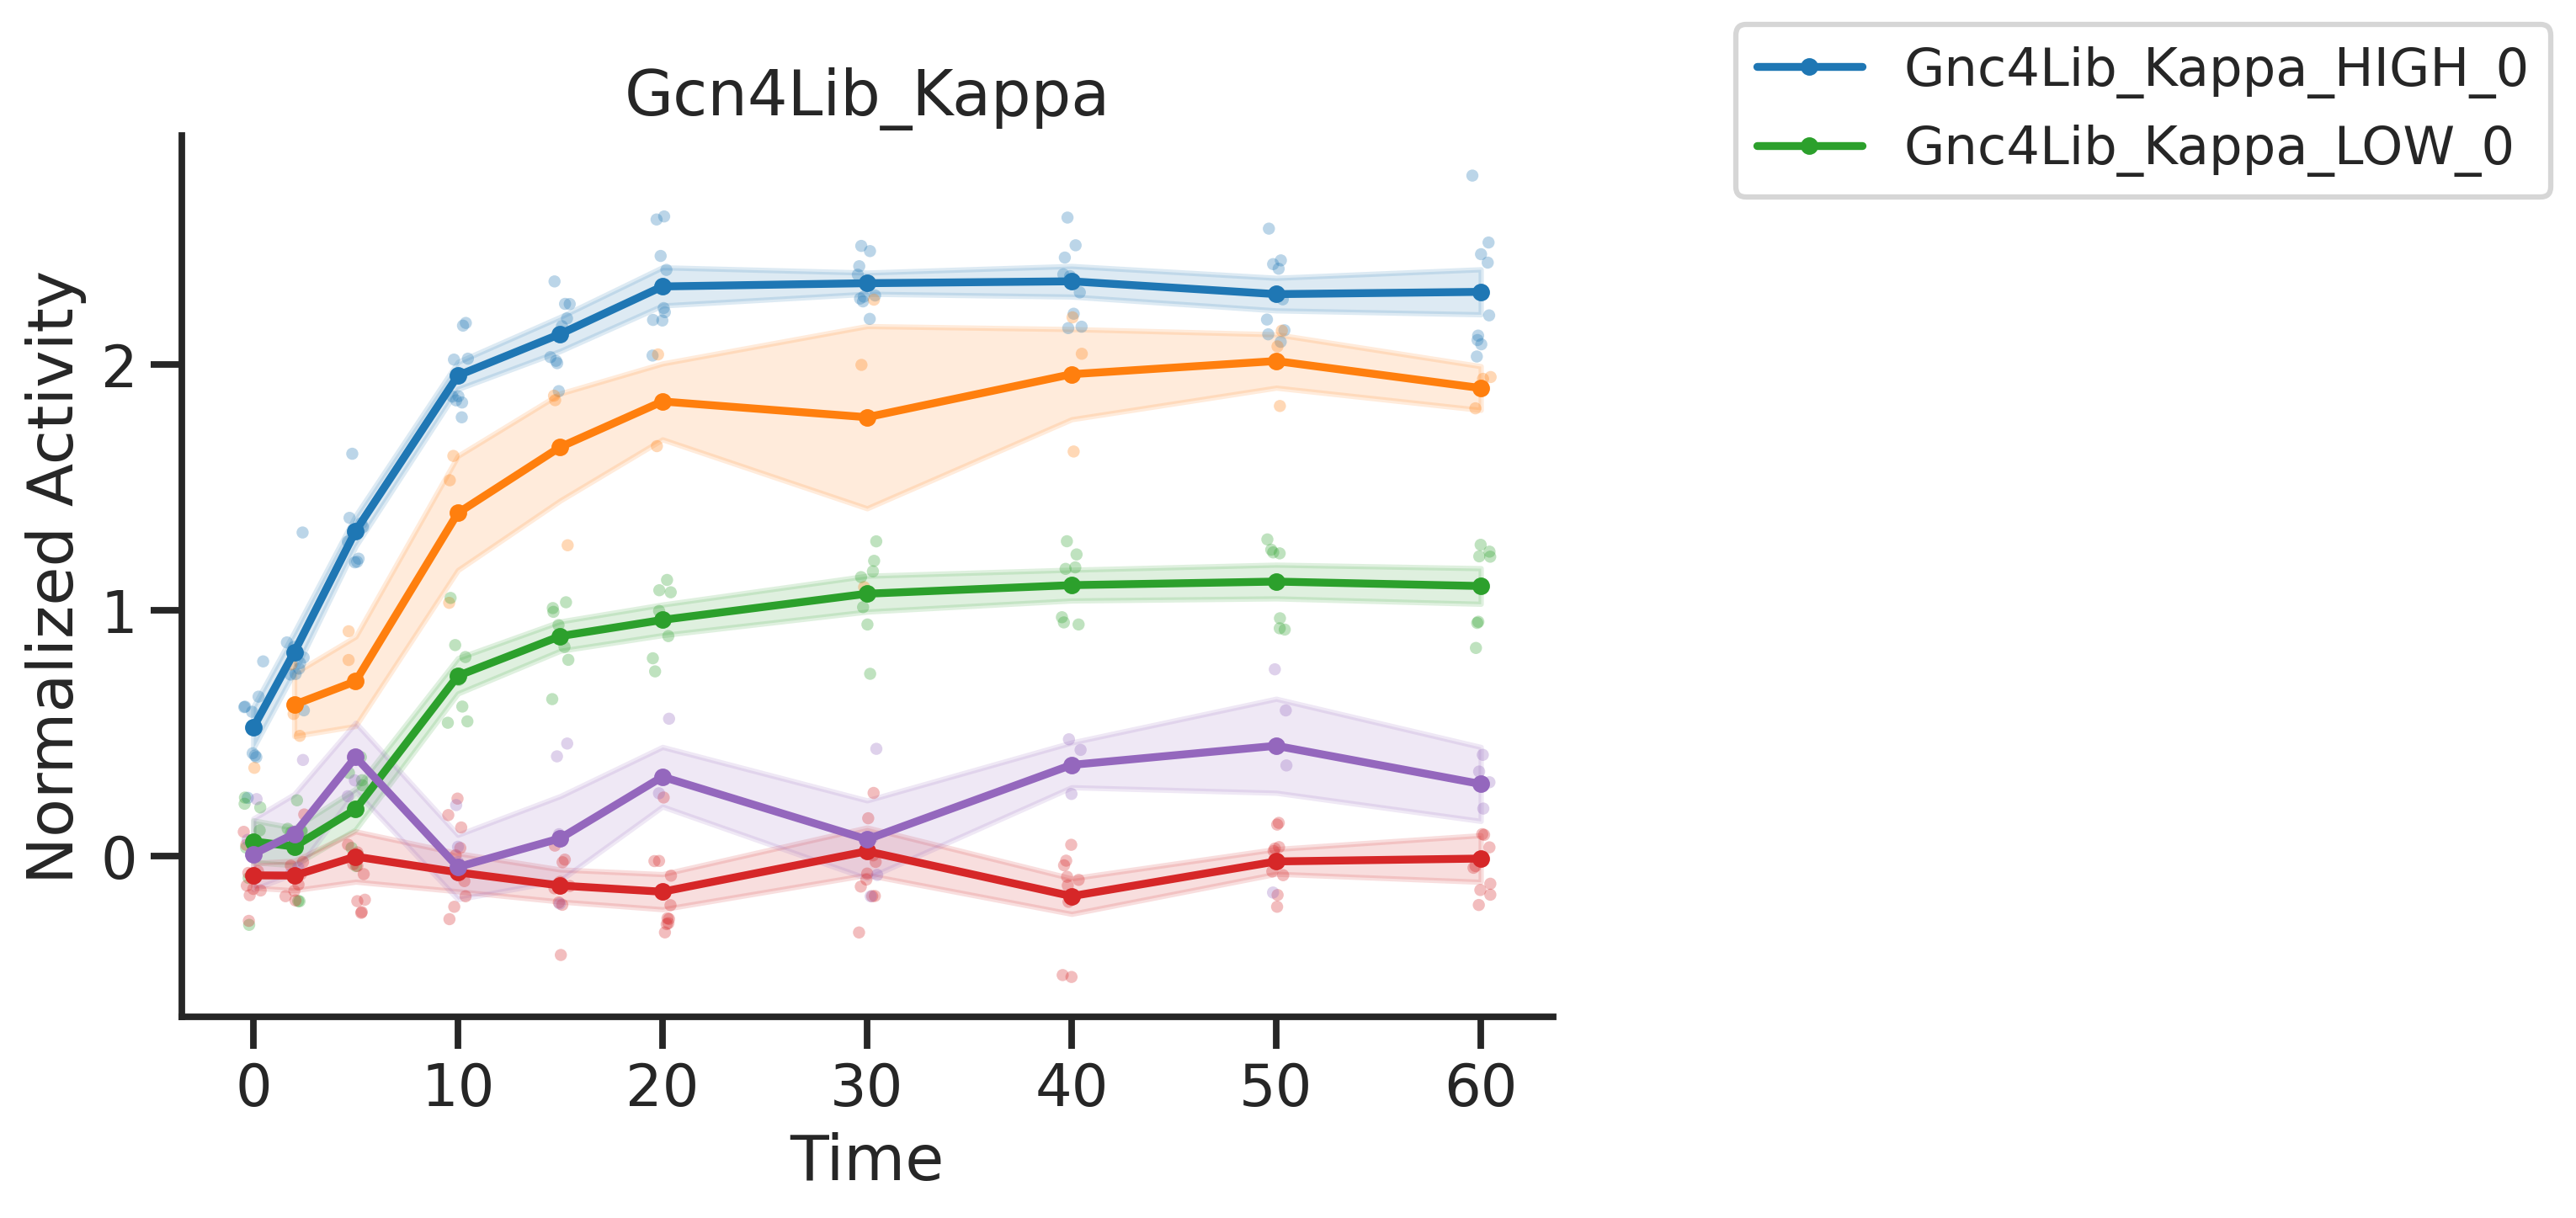

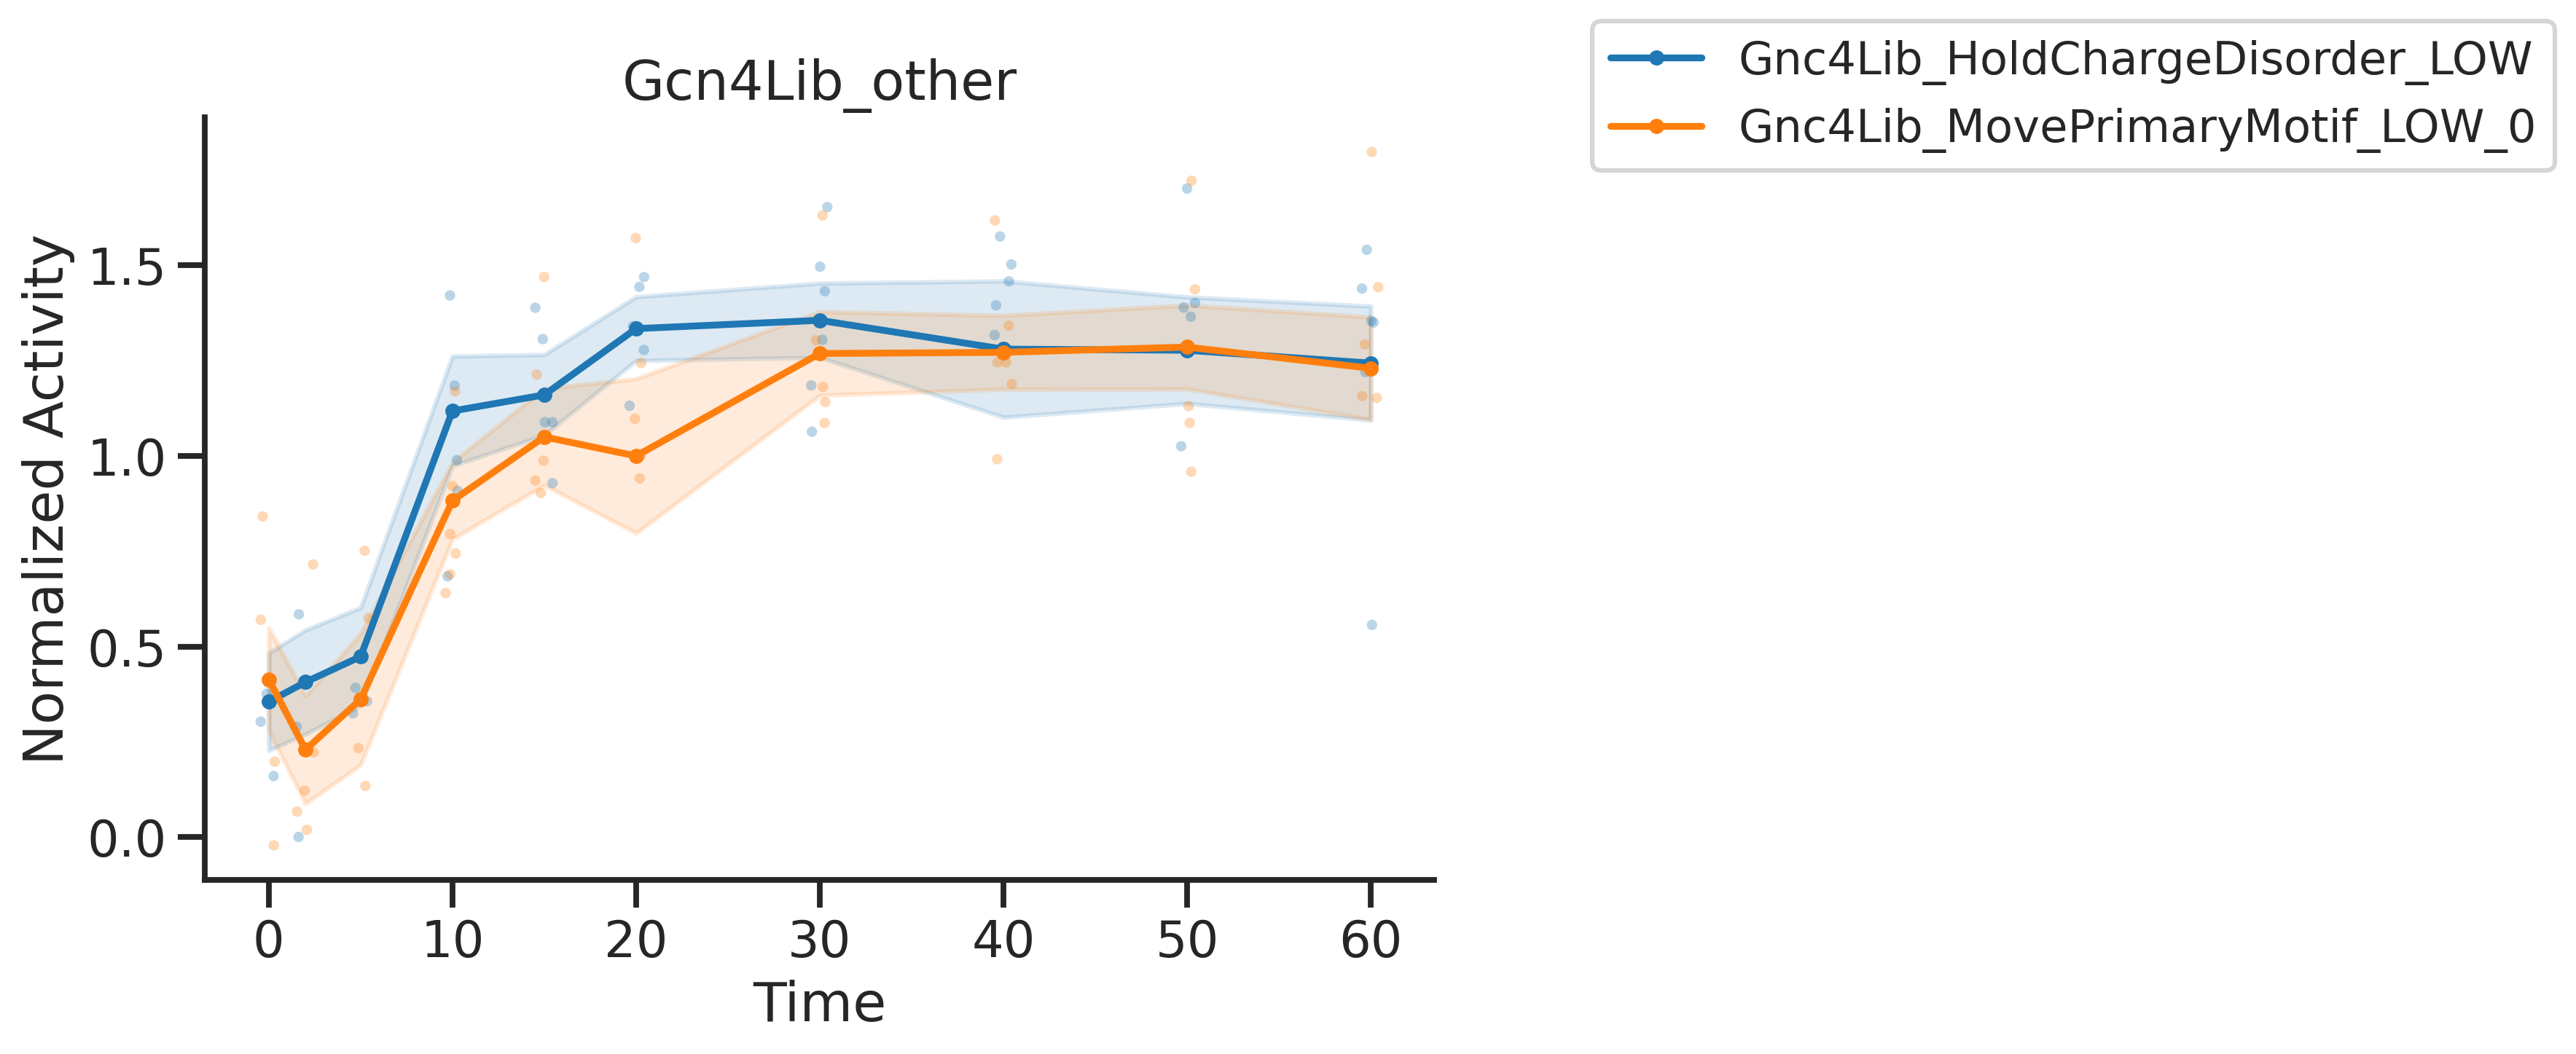

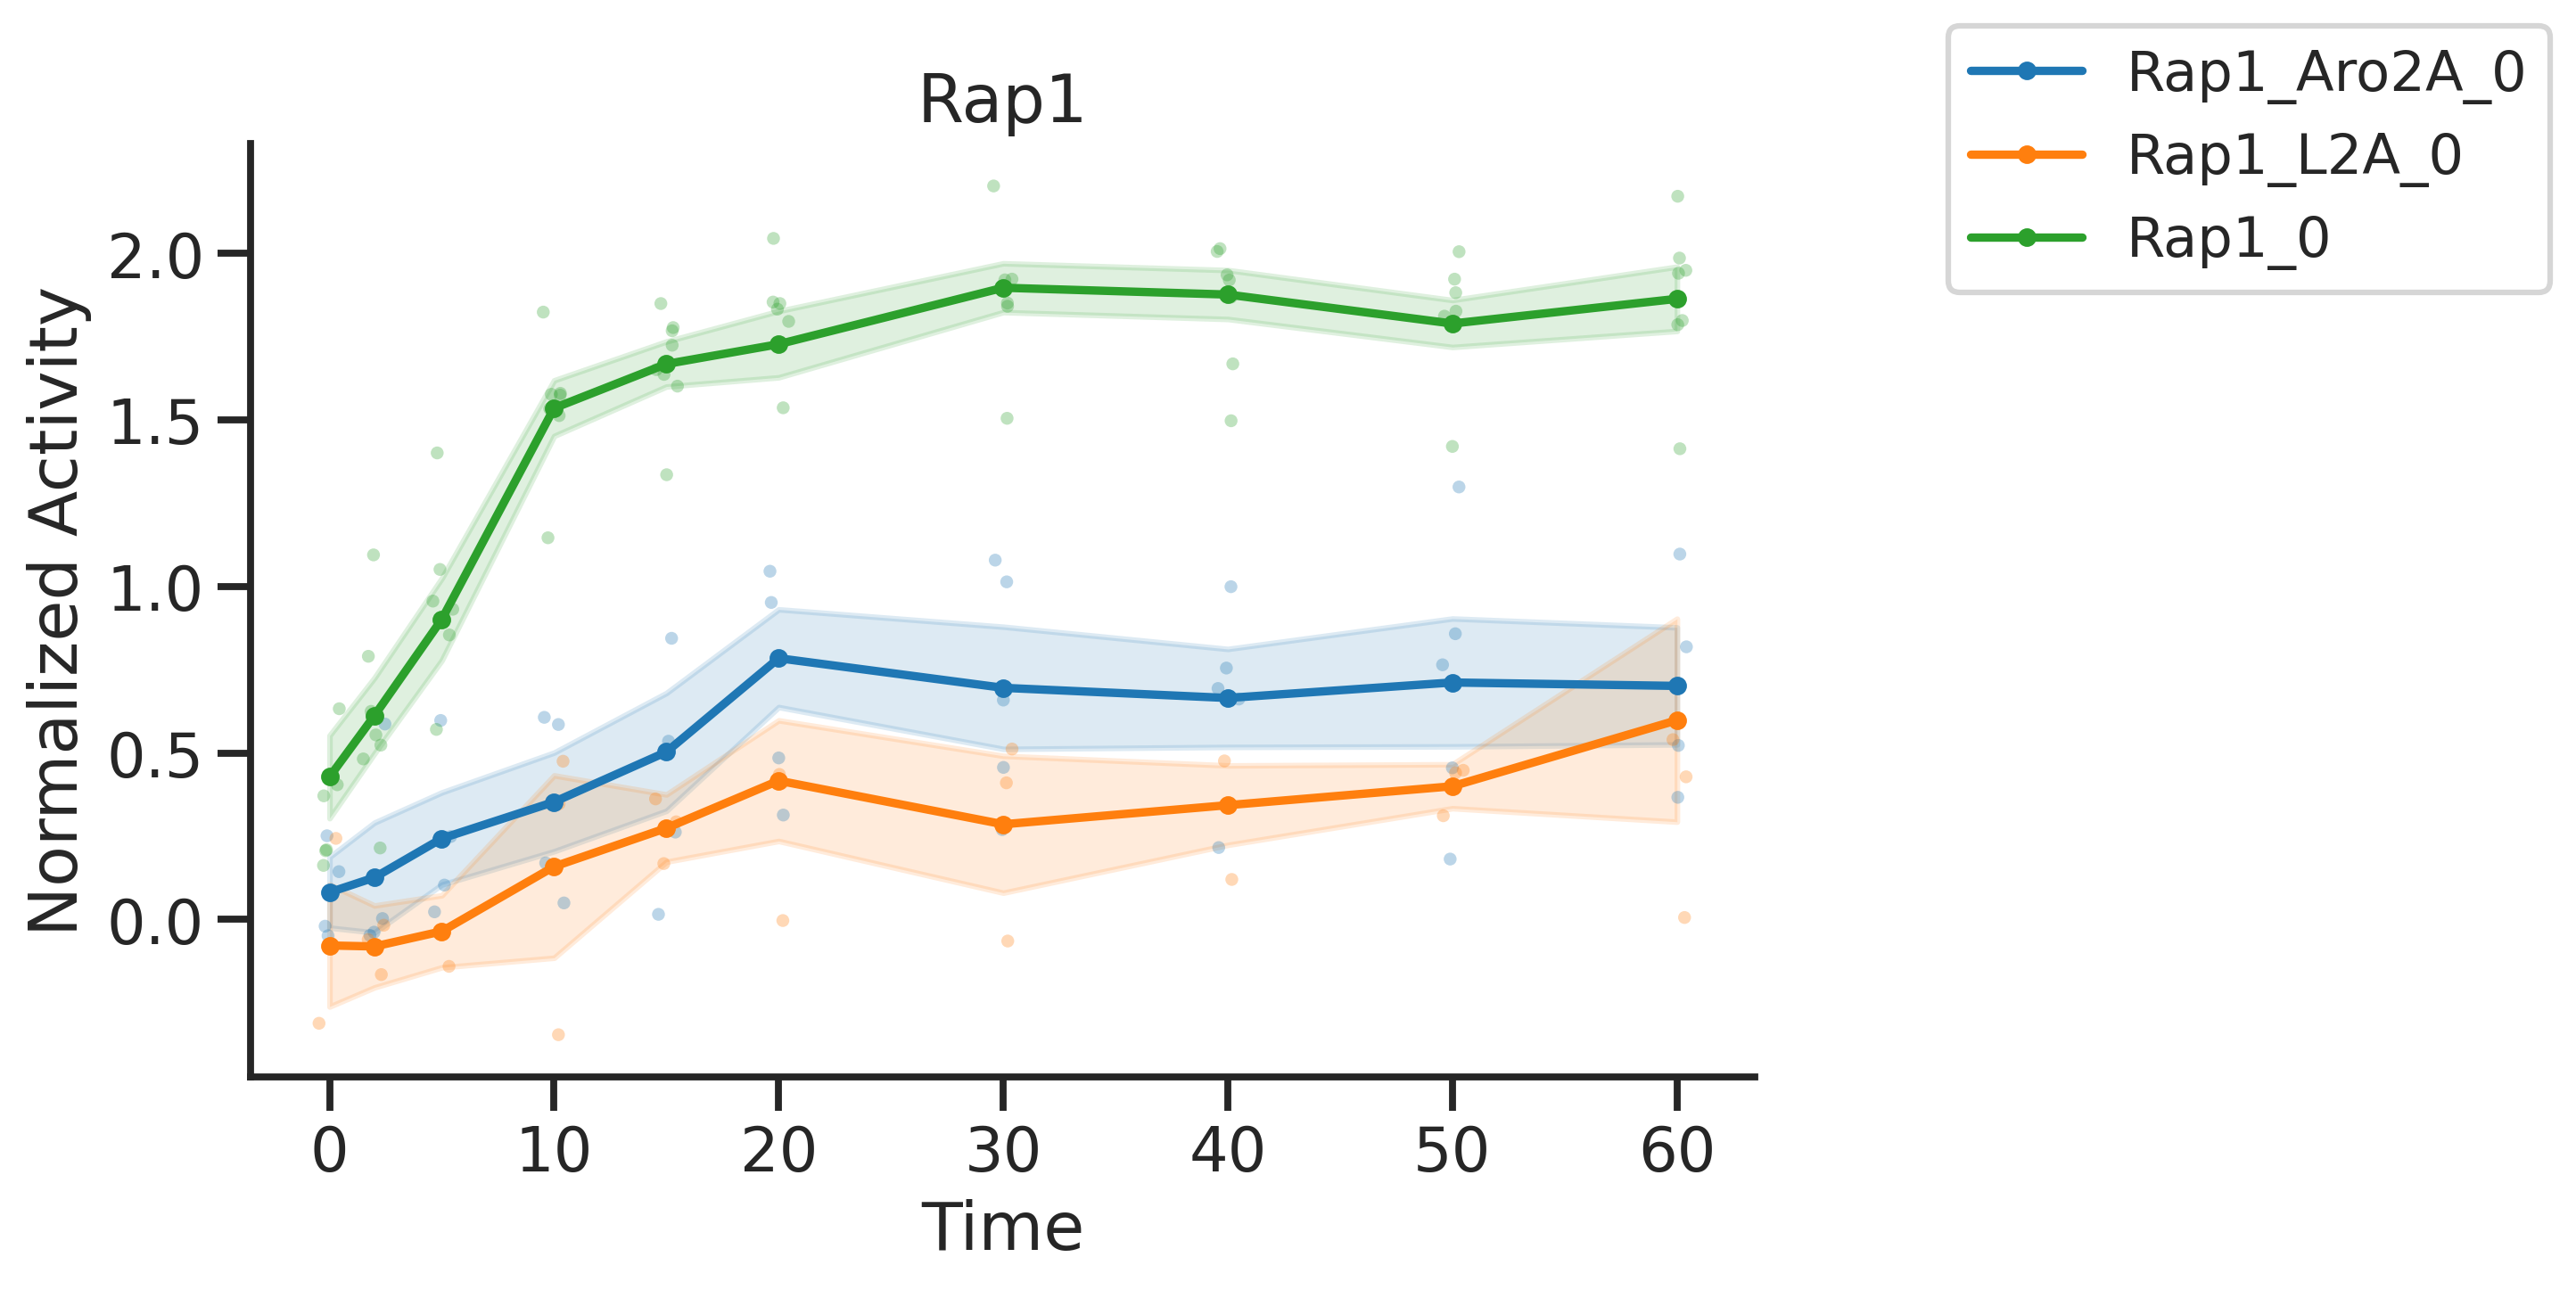

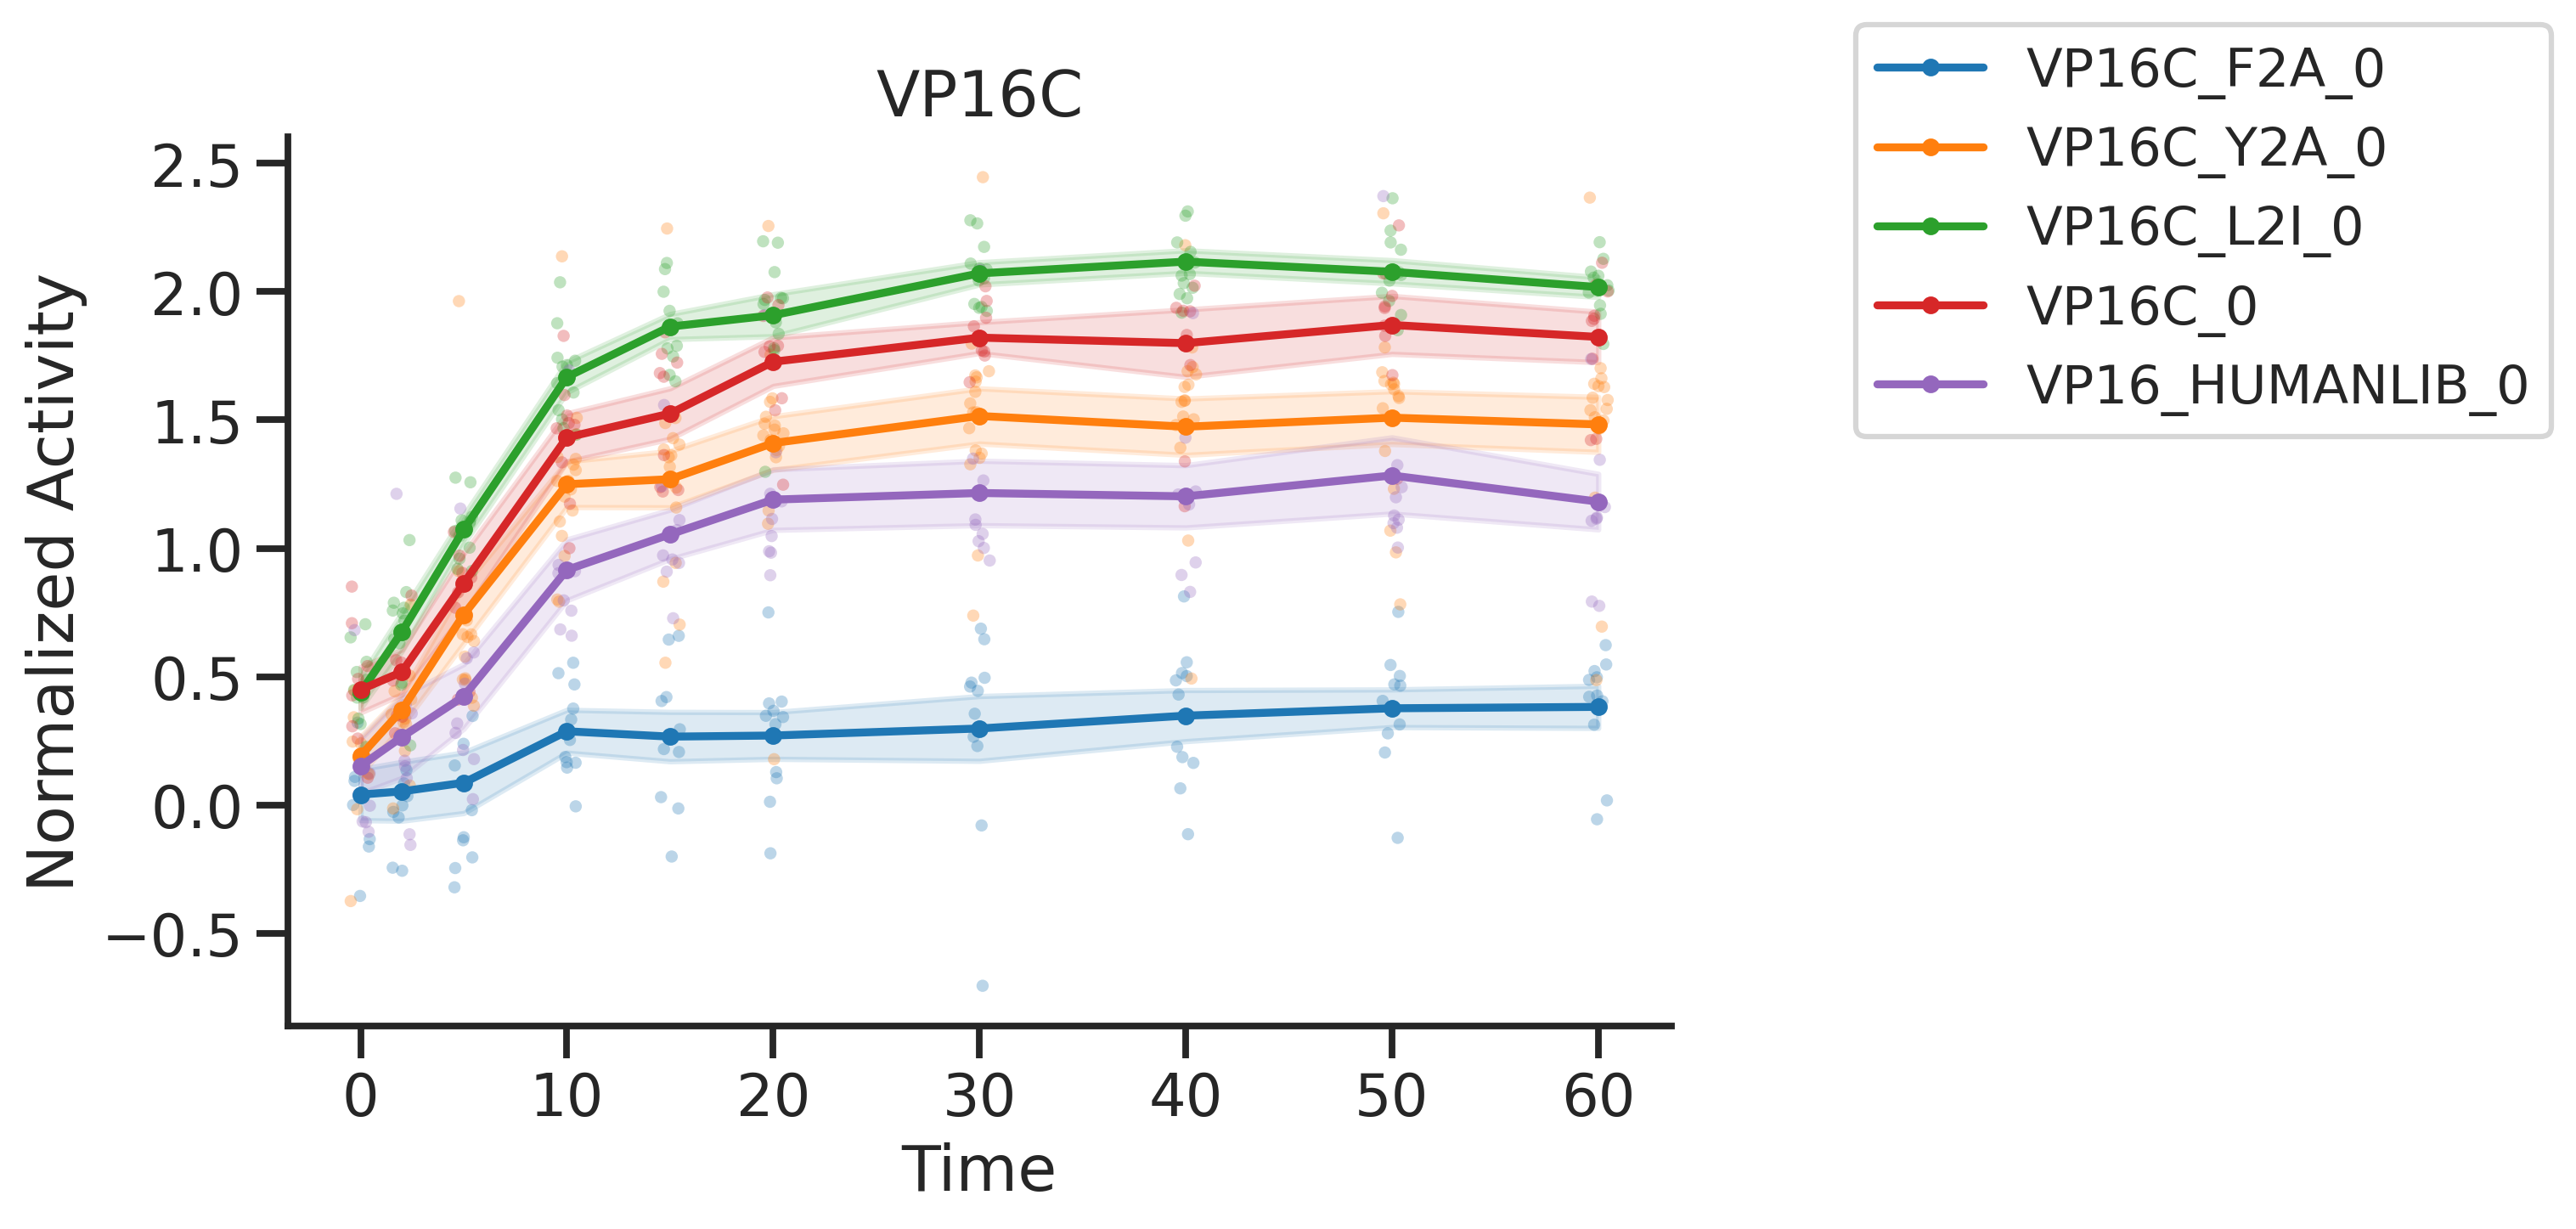

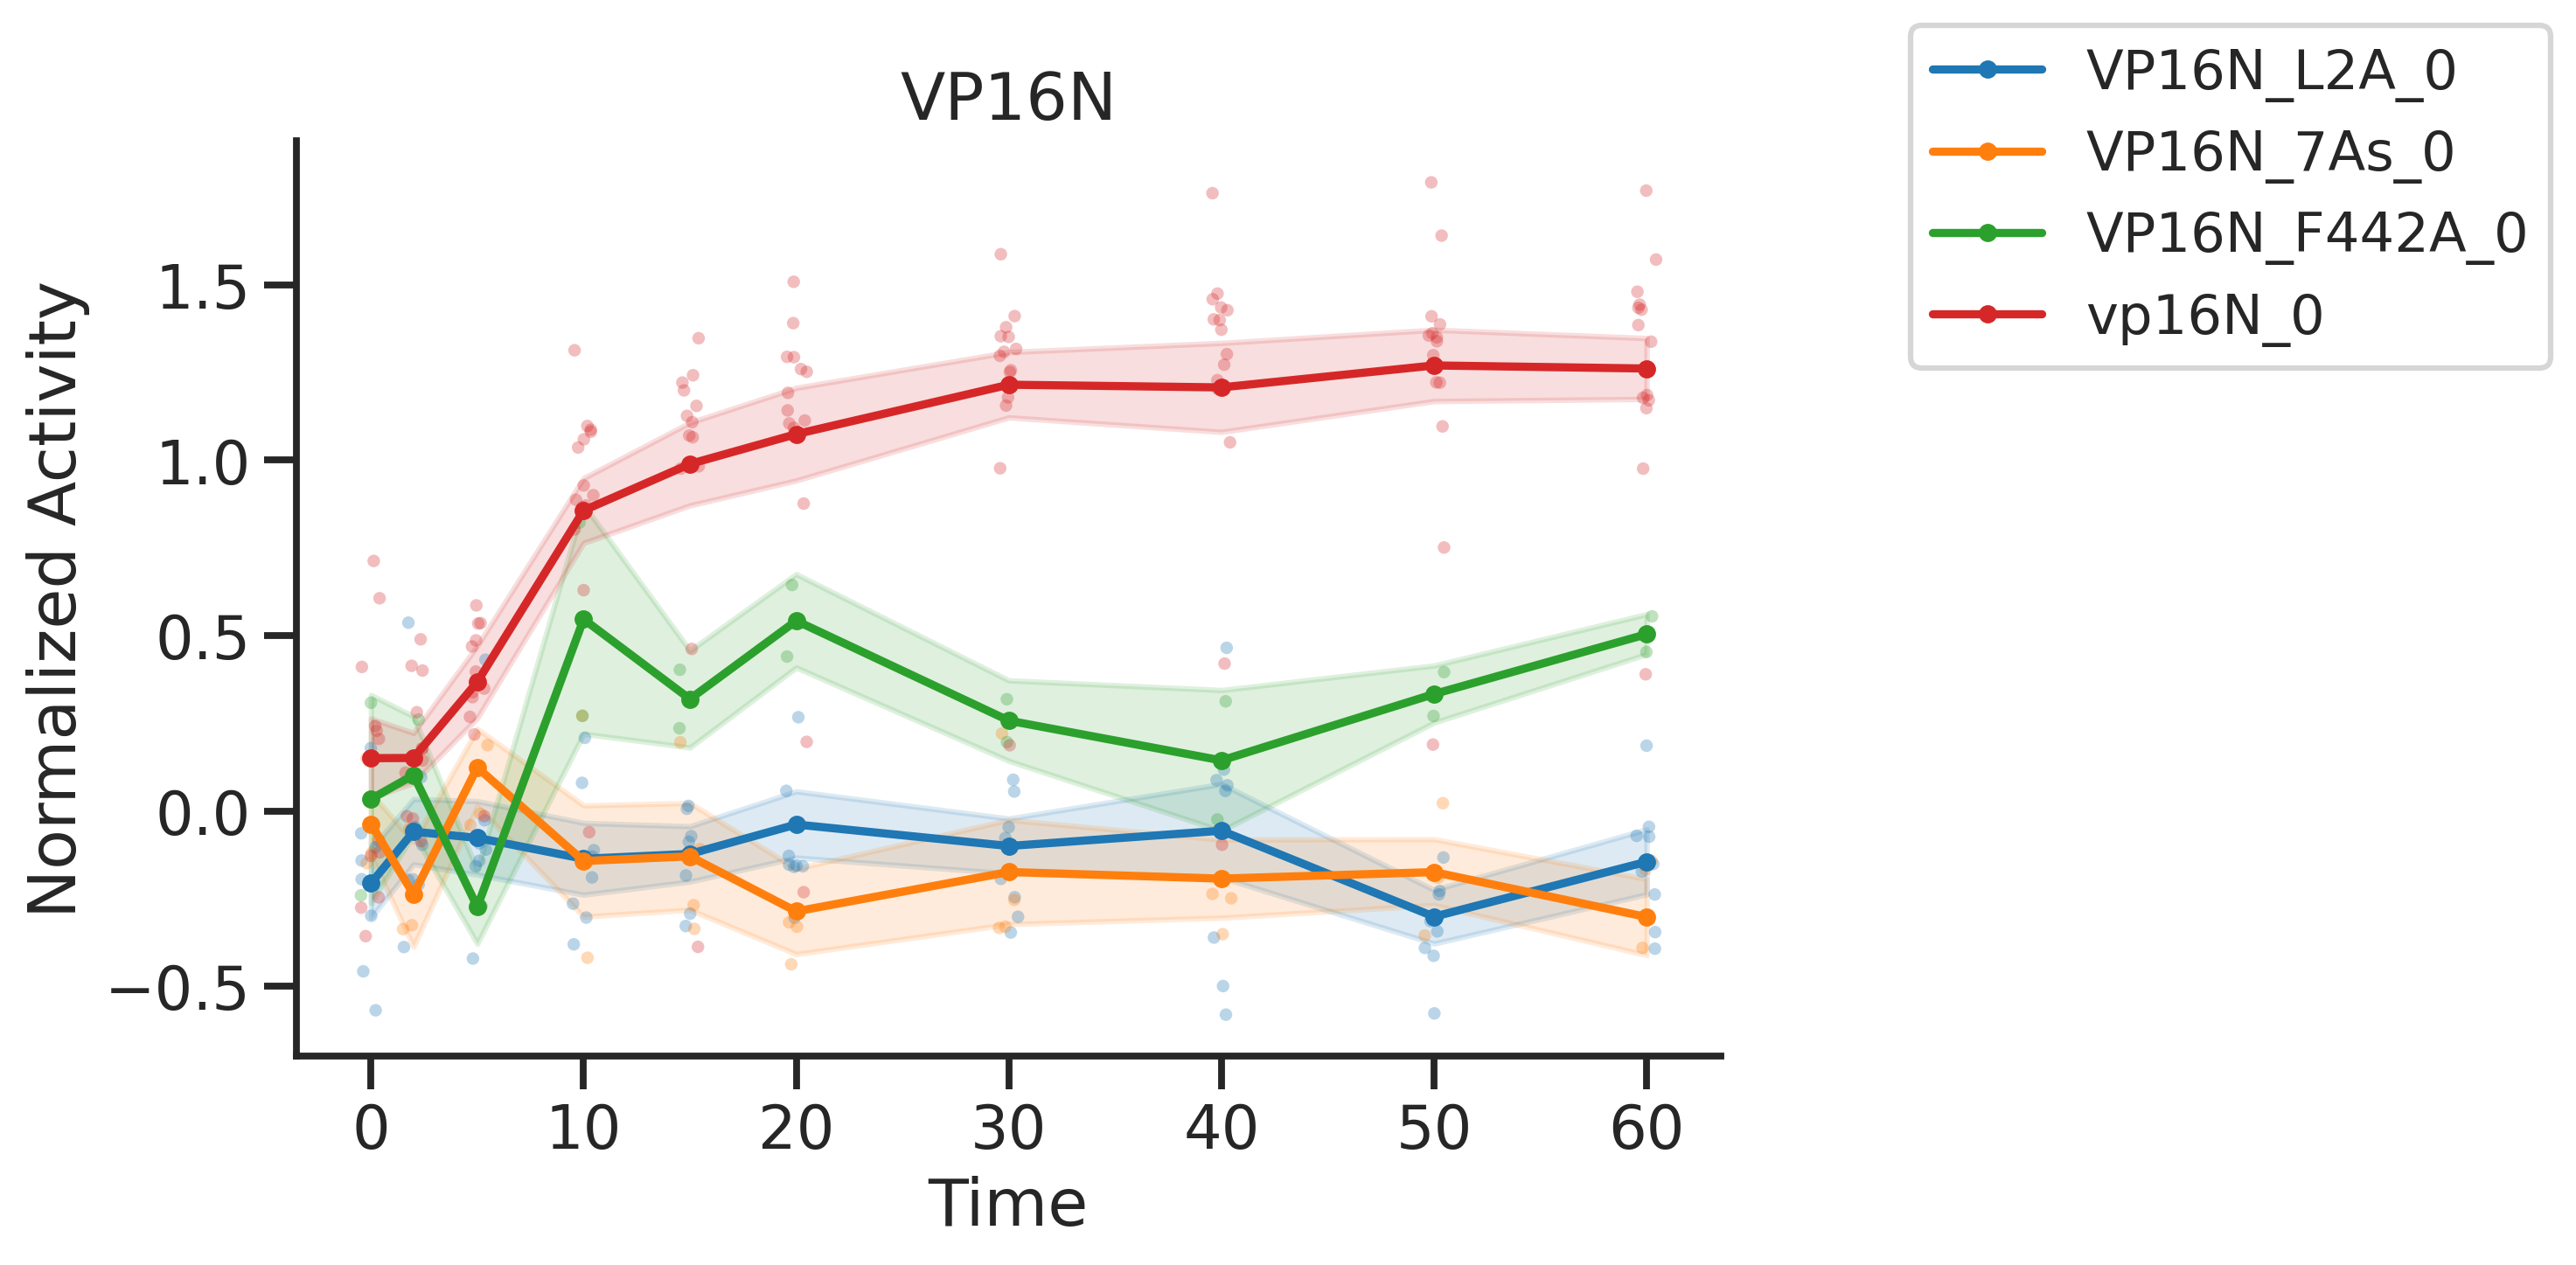

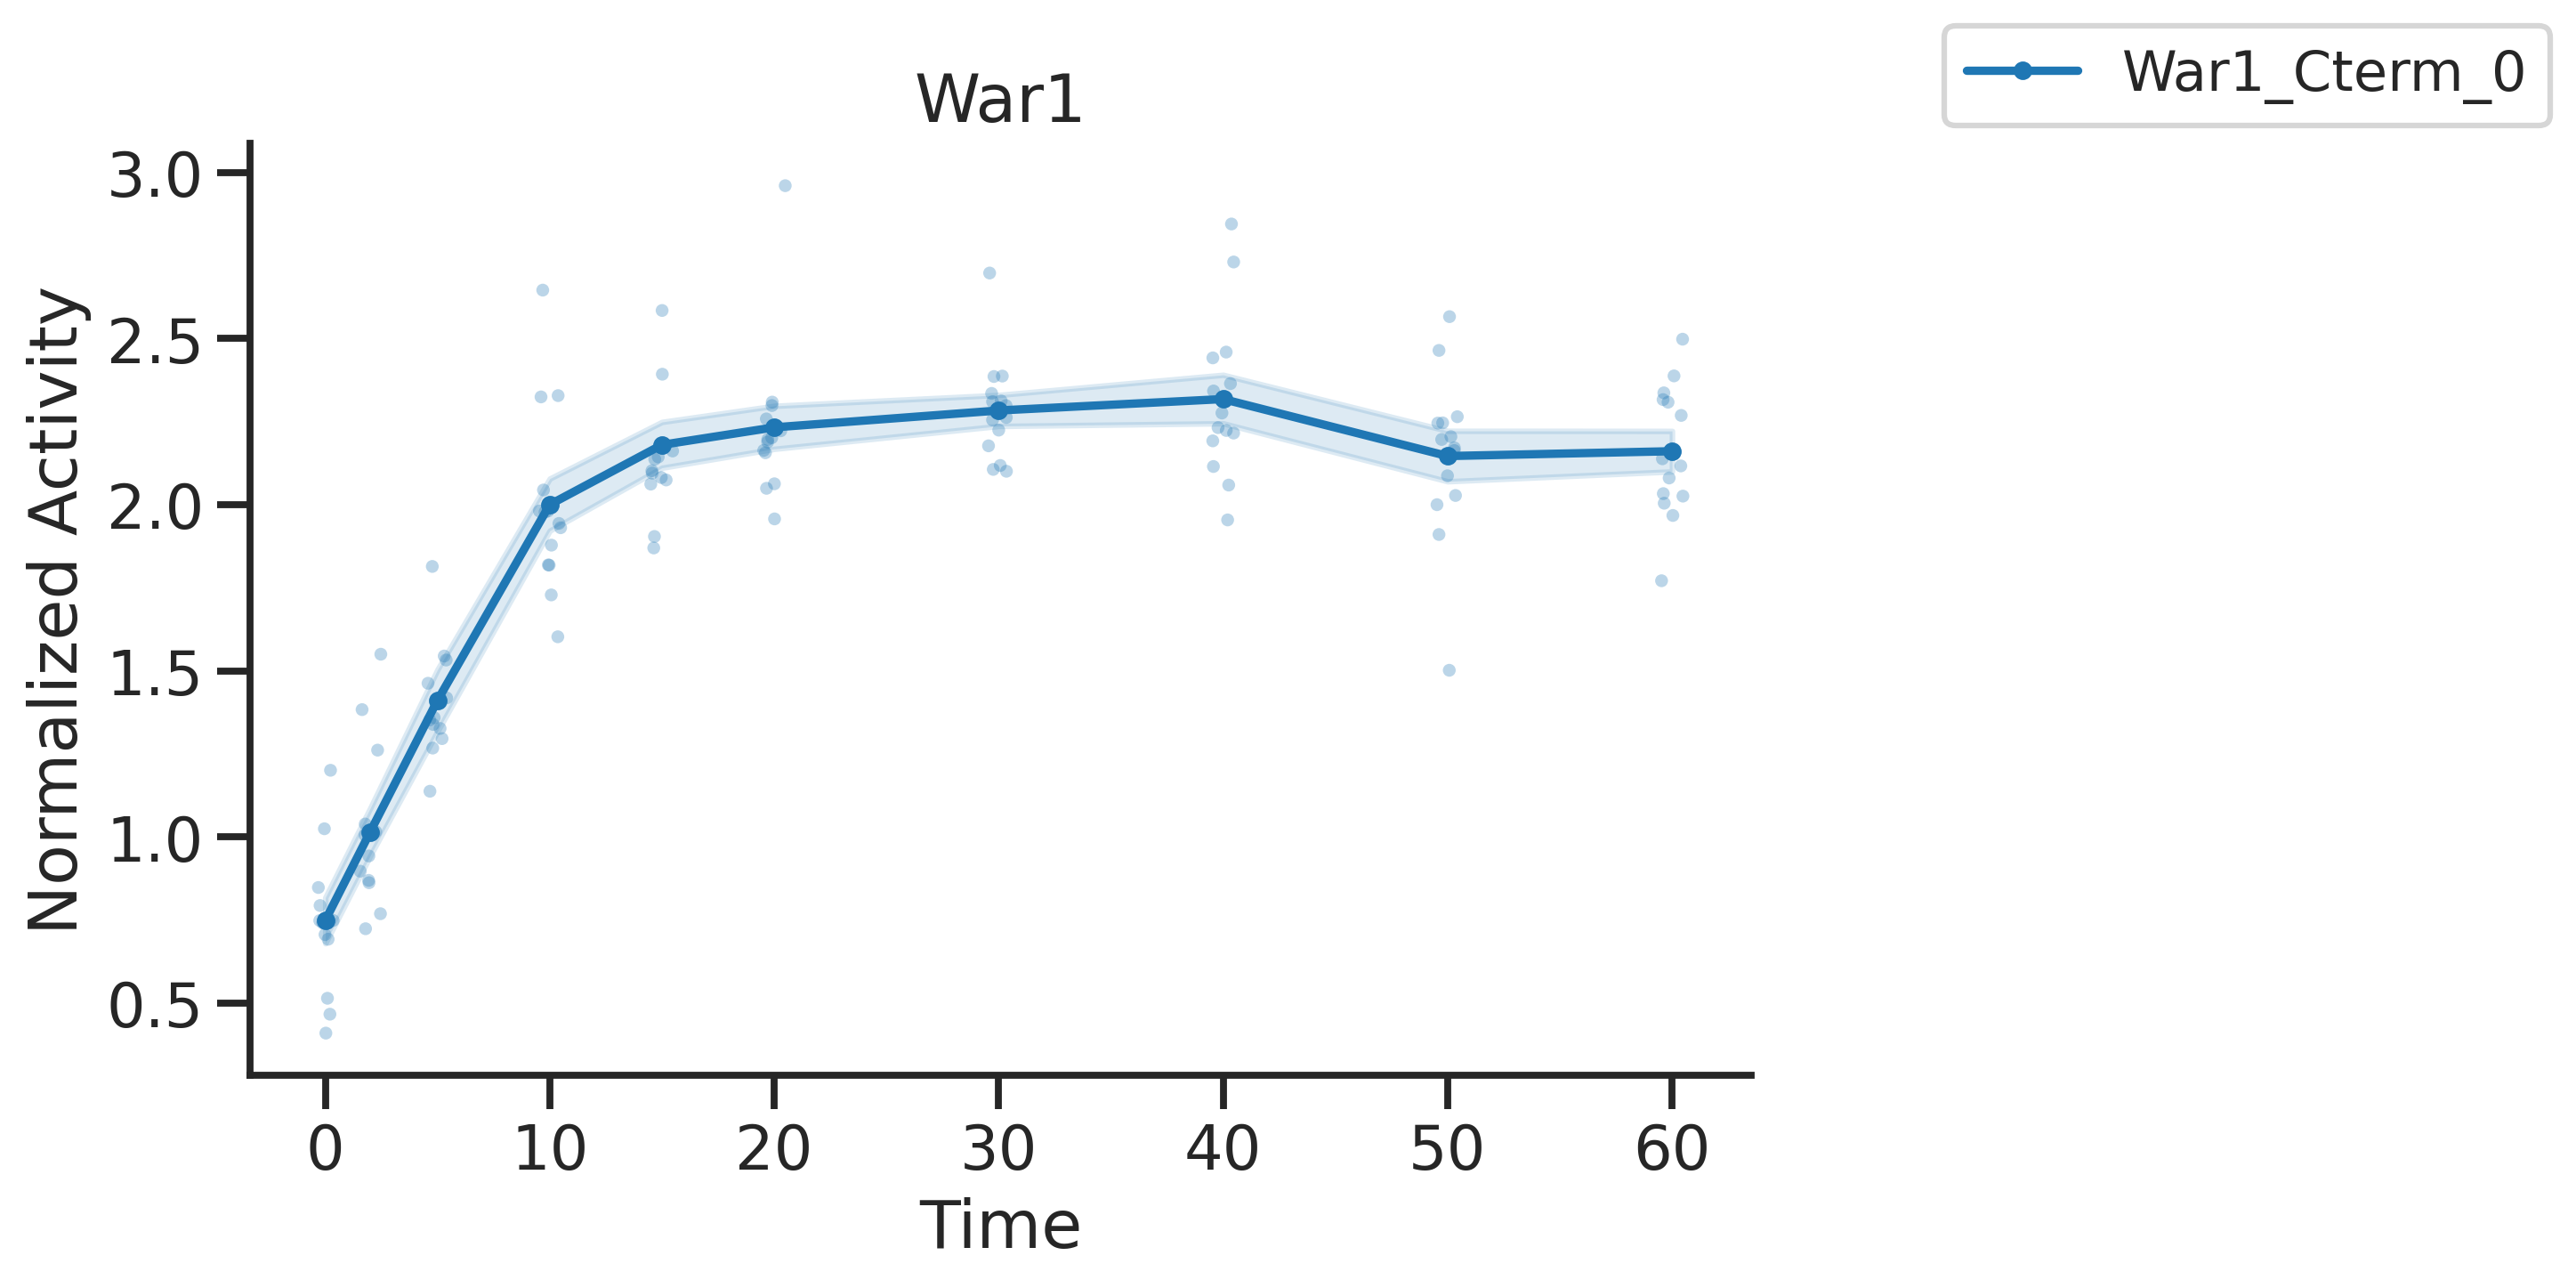

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('ticks')
sns.set_context('talk')

# Use your config
cfg = plot_configs[0]

for group_name in cfg["df"]["group"].unique():
    
    # Filter main mean/SE data
    sub = cfg["df"][cfg["df"]["group"] == group_name].copy()
    
    # Filter tech replicate data
    tech_sub = tech_rep_err_controls[tech_rep_err_controls["group"] == group_name].copy()
    
    # Figure
    fig, ax = plt.subplots(figsize=(7,5), dpi=300)
    
    # Palette by ADseq
    palette = sns.color_palette("tab10", n_colors=sub["ADseq"].nunique())
    
    handles = []
    labels = []
    
    # Plot grand mean ± SE
    for i, (adseq, subdf) in enumerate(sub.groupby("ADseq")):
        subdf = subdf.sort_values("time")
        label = subdf["Name"].iloc[0]
        
        x = subdf["time"]
        y = subdf[cfg["y_mean"]]
        yerr = subdf[cfg["y_std"]]
        color = palette[i]
        
        line, = ax.plot(x, y, color=color, label=label, marker='o', markersize=4)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)
        
        if label not in labels:
            handles.append(line)
            labels.append(label)
    
    # Plot individual tech replicate dots
    for i, (adseq, techdf) in enumerate(tech_sub.groupby("ADseq")):
        techdf = techdf.sort_values("time")
        color = palette[i % len(palette)]  # match grand mean color
        
        # Add slight jitter to x-axis
        x_jittered = techdf["time"] + np.random.uniform(-0.5, 0.5, size=len(techdf))
        
        ax.scatter(
            x_jittered,
            techdf["mean"],
            color=color,
            alpha=0.3,   # lighter
            s=12,        # smaller
            edgecolor='none'
        )
        
    # Labels and title
    ax.set_xlabel("Time")
    ax.set_ylabel("Normalized Activity")
    ax.set_title(group_name)
    
    # Legend outside
    fig.legend(handles, [_[:30] for _ in labels], 
               bbox_to_anchor=(1.05, 1), loc="upper left", fontsize='small', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()